# About the Dataset

Rotten Tomatoes is a popular website that collects movie ratings from both critics and audiences.  
In this project, we use the rotten_tomatoes_movies.csv dataset, which is the most complete and complex file available. It includes detailed information about each movie, such as title, description, genres, cast, runtime, audience score, and critics’ score. Although the data was scraped over several days in October 2020, the dataset still provides strong and rich information for building Machine Learning models.

source: https://www.kaggle.com/datasets/stefanoleone992/rotten-tomatoes-movies-and-critic-reviews-dataset?resource=download

In [2]:
!pip install xgboost

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# For Decision Trees
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree

# For Random Forest
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

# For XGBoost
from xgboost import XGBRegressor, XGBClassifier

SEED = 1

In [4]:
rt_movies_df = pd.read_csv(
    "rotten_tomatoes_movies.csv")
rt_movies_df.head(3)

,rotten_tomatoes_link,movie_title,movie_info,critics_consensus,content_rating,genres,directors,authors,actors,original_release_date,...,production_company,tomatometer_status,tomatometer_rating,tomatometer_count,audience_status,audience_rating,audience_count,tomatometer_top_critics_count,tomatometer_fresh_critics_count,tomatometer_rotten_critics_count
0,m/0814255,Percy Jackson & the Olympians: The Lightning T...,"Always trouble-prone, the life of teenager Per...",Though it may seem like just another Harry Pot...,PG,"Action & Adventure, Comedy, Drama, Science Fic...",Chris Columbus,"Craig Titley, Chris Columbus, Rick Riordan","Logan Lerman, Brandon T. Jackson, Alexandra Da...",2010-02-12,...,20th Century Fox,Rotten,49.0,149.0,Spilled,53.0,254421.0,43,73,76
1,m/0878835,Please Give,Kate (Catherine Keener) and her husband Alex (...,Nicole Holofcener's newest might seem slight i...,R,Comedy,Nicole Holofcener,Nicole Holofcener,"Catherine Keener, Amanda Peet, Oliver Platt, R...",2010-04-30,...,Sony Pictures Classics,Certified-Fresh,87.0,142.0,Upright,64.0,11574.0,44,123,19
2,m/10,10,"A successful, middle-aged Hollywood songwriter...",Blake Edwards' bawdy comedy may not score a pe...,R,"Comedy, Romance",Blake Edwards,Blake Edwards,"Dudley Moore, Bo Derek, Julie Andrews, Robert ...",1979-10-05,...,Waner Bros.,Fresh,67.0,24.0,Spilled,53.0,14684.0,2,16,8


# Data Cleaning / EDA

In [5]:
#17712 rows x 22 columns
rt_movies_df.info

<bound method DataFrame.info of                         rotten_tomatoes_link  \
0                                  m/0814255   
1                                  m/0878835   
2                                       m/10   
3                     m/1000013-12_angry_men   
4      m/1000079-20000_leagues_under_the_sea   
...                                      ...   
17707                            m/zoot_suit   
17708                             m/zootopia   
17709                      m/zorba_the_greek   
17710                                 m/zulu   
17711                            m/zulu_dawn   

                                             movie_title  \
0      Percy Jackson & the Olympians: The Lightning T...   
1                                            Please Give   
2                                                     10   
3                        12 Angry Men (Twelve Angry Men)   
4                           20,000 Leagues Under The Sea   
...                            

In [6]:
rt_movies_df.describe()

,runtime,tomatometer_rating,tomatometer_count,audience_rating,audience_count,tomatometer_top_critics_count,tomatometer_fresh_critics_count,tomatometer_rotten_critics_count
count,17398.000000,17668.000000,17668.000000,17416.000000,1.741500e+04,17712.000000,17712.000000,17712.000000
mean,102.214048,60.884763,57.139801,60.554260,1.439401e+05,14.586326,36.374831,20.703139
std,18.702511,28.443348,68.370047,20.543369,1.763577e+06,15.146349,52.601038,30.248435
min,5.000000,0.000000,5.000000,0.000000,5.000000e+00,0.000000,0.000000,0.000000
25%,90.000000,38.000000,12.000000,45.000000,7.075000e+02,3.000000,6.000000,3.000000
50%,99.000000,67.000000,28.000000,63.000000,4.277000e+03,8.000000,16.000000,8.000000
75%,111.000000,86.000000,75.000000,78.000000,2.498800e+04,23.000000,44.000000,24.000000
max,266.000000,100.000000,574.000000,100.000000,3.579764e+07,69.000000,497.000000,303.000000


In [7]:
rt_movies_df.dtypes

rotten_tomatoes_link                 object
movie_title                          object
movie_info                           object
critics_consensus                    object
content_rating                       object
genres                               object
directors                            object
authors                              object
actors                               object
original_release_date                object
streaming_release_date               object
runtime                             float64
production_company                   object
tomatometer_status                   object
tomatometer_rating                  float64
tomatometer_count                   float64
audience_status                      object
audience_rating                     float64
audience_count                      float64
tomatometer_top_critics_count         int64
tomatometer_fresh_critics_count       int64
tomatometer_rotten_critics_count      int64
dtype: object

In [8]:
# Count duplicated rows in the DataFrame --- No Duplicate values to drop off!
rt_movies_df.duplicated().sum()

np.int64(0)

In [9]:
# Count duplicated rows in "movie_title" column --- 606 rows
# That´s happens because there is more than 1 review per movie

rt_movies_df["movie_title"].duplicated().sum()

np.int64(606)

In [10]:
#Let´s keep just one review per movie and keep those with the highest audience_count.
rt_movies_df = (
    rt_movies_df.sort_values("audience_count", ascending=False)
                .drop_duplicates(subset=["movie_title"], keep="first")
                .reset_index(drop=True)
)

In [11]:
# Done. No duplicates on this column
rt_movies_df["movie_title"].duplicated().sum()

np.int64(0)

In [12]:
rt_movies_df.columns

Index(['rotten_tomatoes_link', 'movie_title', 'movie_info',
       'critics_consensus', 'content_rating', 'genres', 'directors', 'authors',
       'actors', 'original_release_date', 'streaming_release_date', 'runtime',
       'production_company', 'tomatometer_status', 'tomatometer_rating',
       'tomatometer_count', 'audience_status', 'audience_rating',
       'audience_count', 'tomatometer_top_critics_count',
       'tomatometer_fresh_critics_count', 'tomatometer_rotten_critics_count'],
      dtype='object')

In [13]:
# Drop off no relevant columns for this first moment
rt_movies_df = rt_movies_df.drop(
    ['rotten_tomatoes_link','movie_info','critics_consensus','tomatometer_count',
     'audience_status','tomatometer_top_critics_count',
     'tomatometer_fresh_critics_count','tomatometer_rotten_critics_count'],
    axis=1
)

In [14]:
rt_movies_df.head(5)

,movie_title,content_rating,genres,directors,authors,actors,original_release_date,streaming_release_date,runtime,production_company,tomatometer_status,tomatometer_rating,audience_rating,audience_count
0,Titanic,PG-13,"Drama, Romance",James Cameron,James Cameron,"Leonardo DiCaprio, Kate Winslet, Billy Zane, K...",1997-12-19,2014-06-01,195.0,Paramount Pictures,Certified-Fresh,89.0,69.0,35797635.0
1,The Lord of the Rings: The Return of the King,PG-13,"Action & Adventure, Classics, Science Fiction ...",Peter Jackson,"Fran Walsh, Philippa Boyens, Peter Jackson","Elijah Wood, Sean Astin, Ian McKellen, Andy Se...",2003-12-17,2010-04-06,200.0,New Line Cinema,Certified-Fresh,93.0,86.0,34679773.0
2,Spider-Man,PG-13,"Action & Adventure, Mystery & Suspense, Scienc...",Sam Raimi,David Koepp,"Tobey Maguire, Kirsten Dunst, Willem Dafoe, Ja...",2002-05-03,2013-04-25,116.0,Columbia Pictures,Certified-Fresh,90.0,67.0,34297354.0
3,Shrek 2,PG,"Animation, Comedy, Kids & Family, Science Fict...","Conrad Vernon, Andrew Adamson, Kelly Asbury","Joe Stillman, David N. Weiss, J. David Stern, ...","Mike Myers, John Cleese, Jonathan Ross, Jennif...",2004-05-19,2015-11-25,92.0,Dreamworks,Certified-Fresh,89.0,69.0,34232524.0
4,Harry Potter and the Goblet of Fire,PG-13,"Action & Adventure, Kids & Family, Science Fic...",Mike Newell,Steve Kloves,"Daniel Radcliffe, Rupert Grint, Emma Watson, R...",2005-11-18,2008-01-01,157.0,Warner Bros. Pictures,Certified-Fresh,88.0,74.0,34153607.0


In [15]:
rt_movies_df.columns

Index(['movie_title', 'content_rating', 'genres', 'directors', 'authors',
       'actors', 'original_release_date', 'streaming_release_date', 'runtime',
       'production_company', 'tomatometer_status', 'tomatometer_rating',
       'audience_rating', 'audience_count'],
      dtype='object')

In [16]:
# We want to use "tomatometer_status" as target. Let´s check the column unique values
rt_movies_df ["tomatometer_status"].unique()

array(['Certified-Fresh', 'Fresh', 'Rotten', nan], dtype=object)

In [17]:
# Check "tomatometer_status" null values
rt_movies_df["tomatometer_status"].isna().sum()

np.int64(43)

In [18]:
# Drop off "tomatometer_status" null values
rt_movies_df = rt_movies_df.dropna(subset=['tomatometer_status'])

In [19]:
rt_movies_df["tomatometer_status"].isna().sum()

np.int64(0)

In [20]:
# Considering that:
# Certified Fresh: A special badge given to films that have 75% or higher positive reviews
# Fresh: A film with 60% or more positive reviews from critics
# Rotten: A film with less than 60% positive reviews from professional critics

# Let’s use 60% as the threshold and keep just two categories: “Fresh” (>60%) and “Rotten” (<60%)

rt_movies_df['tomatometer_status'] = rt_movies_df['tomatometer_rating'].apply(
    lambda x: "Fresh" if x >= 60 else "Rotten"
)

In [21]:
# Final "tomatometer_status" values
rt_movies_df ["tomatometer_status"].unique()

array(['Fresh', 'Rotten'], dtype=object)

In [22]:
# Once we have a robust dataframe, we’ll use “audience_count” as a popularity indicator and keep only the rows with more than 2500 reviews (1% more accuracy)
filtered_rt_df = rt_movies_df[
    rt_movies_df["audience_count"] > 3500
].copy()

In [23]:
filtered_rt_df.info

<bound method DataFrame.info of                                             movie_title content_rating  \
0                                               Titanic          PG-13   
1         The Lord of the Rings: The Return of the King          PG-13   
2                                            Spider-Man          PG-13   
3                                               Shrek 2             PG   
4                   Harry Potter and the Goblet of Fire          PG-13   
...                                                 ...            ...   
8930                                          Bandolero          PG-13   
8931  Incubo sulla città contaminata (Nightmare City...              R   
8932                                               Here             NR   
8933                             Fat Man and Little Boy          PG-13   
8934                                      No Such Thing              R   

                                                 genres  \
0                   

### Features categorization

### 1 - "content_rating" column

In [24]:
filtered_rt_df['content_rating'].unique()

array(['PG-13', 'PG', 'R', 'G', 'NR', 'NC17'], dtype=object)

In [25]:
# Considering that:
# G → General Audience → suitable for all ages
# PG → Parental Guidance → children may watch, but with supervision
# PG‑13 → Parents Strongly Cautioned → recommended for ages 13 and up
# R → Restricted → ages 17 (or 18) and up
# NC‑17 → No Children → prohibited for anyone under 17
# NR → no rating

# Let's transform these values into four main categories: 'Family', 'Adult', 'Unknown', 'Teen'

def simplify_rating(r):
    if r in ["G", "PG"]:
        return "Family"
    elif r in ["PG-13"]:
        return "Teen"
    elif r in ["R", "NC-17"]:
        return "Adult"
    else:
        return "Unknown"

filtered_rt_df["content_group"] = filtered_rt_df["content_rating"].apply(simplify_rating)

In [26]:
filtered_rt_df["content_group"].unique()

array(['Teen', 'Family', 'Adult', 'Unknown'], dtype=object)

### 2 - "genres" column

In [27]:
filtered_rt_df["genres"].unique()

array(['Drama, Romance',
       'Action & Adventure, Classics, Science Fiction & Fantasy',
       'Action & Adventure, Mystery & Suspense, Science Fiction & Fantasy',
       'Animation, Comedy, Kids & Family, Science Fiction & Fantasy',
       'Action & Adventure, Kids & Family, Science Fiction & Fantasy',
       'Action & Adventure, Classics, Drama',
       'Kids & Family, Science Fiction & Fantasy', 'Comedy',
       'Action & Adventure',
       'Action & Adventure, Drama, Science Fiction & Fantasy',
       'Action & Adventure, Comedy, Mystery & Suspense',
       'Drama, Sports & Fitness', 'Animation, Comedy, Kids & Family',
       'Action & Adventure, Science Fiction & Fantasy',
       'Action & Adventure, Comedy', 'Comedy, Science Fiction & Fantasy',
       'Comedy, Romance', 'Action & Adventure, Drama, Mystery & Suspense',
       'Comedy, Drama',
       'Action & Adventure, Drama, Mystery & Suspense, Science Fiction & Fantasy',
       'Action & Adventure, Comedy, Drama', 'Comedy, H

In [28]:
# Let´s create a "genres_list" column (cleaning + split)

filtered_rt_df["genres_list"] = (
    filtered_rt_df["genres"]
    .fillna("")
    .apply(lambda x: [g.strip() for g in x.split(",")] if isinstance(x, str) else [])
)

In [29]:
# Now let’s create a dictionary to simplify the genres column and keep just one main genre per movie.
# We used AI assistance to design the following distribution:

genre_map = {
    # ACTION
    # Genres related to physical conflict, adventure, or high-energy storytelling
    "Action & Adventure": "Action",
    "Action": "Action",
    "Adventure": "Action",
    "Western": "Action",
    "Sports & Fitness": "Action",  # often associated with competitive or physical themes
    "Cult Movies": "Action",       # frequently overlaps with action or genre-heavy films

    # COMEDY
    # Genres focused on humor, light-hearted storytelling, or comedic performance
    "Comedy": "Comedy",
    "Gay & Lesbian": "Comedy",     # appears mostly in comedic or light narratives
    "Television": "Comedy",        # often used in comedic TV formats
    "Musical & Performing Arts": "Comedy",  # frequently linked to comedic musicals

    # DRAMA
    # Genres centered on emotional, narrative-driven, or classic storytelling
    "Drama": "Drama",
    "Classics": "Drama",
    "Art House & International": "Drama",
    "Faith & Spirituality": "Drama",
    "Special Interest": "Drama",   # appears in drama-heavy or thematic films
    "Sports & Fitness": "Drama",   # when paired with dramatic narratives

    # ROMANCE
    # Genres focused on romantic relationships or emotional connection
    "Romance": "Romance",

    # SCI-FI
    # Genres involving futuristic, speculative, or fantastical elements
    "Science Fiction & Fantasy": "Sci-Fi",
    "Science Fiction": "Sci-Fi",
    "Fantasy": "Sci-Fi",
    "Anime & Manga": "Sci-Fi",

    # HORROR
    # Genres involving fear, supernatural elements, or dark themes
    "Horror": "Horror",

    # SUSPENSE
    # Genres involving tension, mystery, or investigative storytelling
    "Mystery & Suspense": "Suspense",
    "Suspense": "Suspense",
    "Mystery": "Suspense",

    # DOCUMENTARY
    # Genres focused on real events, factual storytelling, or non-fiction
    "Documentary": "Documentary",

    # FAMILY
    # Genres aimed at children, families, or animated storytelling
    "Animation": "Family",
    "Kids & Family": "Family",

    # OTHER
    # Genres that do not consistently map to a single main category
    "Television": "Other",
    "Cult Movies": "Other",
    "Special Interest": "Other",
    "Sports & Fitness": "Other",
    "Gay & Lesbian": "Other",
    "Musical & Performing Arts": "Other"
}

In [30]:
# Define a priority order for genre selection.
# This list determines which genre should be chosen as the main genre

priority = [
    "Action",
    "Comedy",
    "Drama",
    "Romance",
    "Sci-Fi",
    "Horror",
    "Suspense",
    "Documentary",
    "Family",
    "Other"
]

In [31]:
def get_main_genre(genre_list):
    mapped = []

    # Convert each original genre into one of the simplified categories
    # using the genre_map dictionary. Only genres present in the dictionary
    # will be added to the mapped list.
    for g in genre_list:
        if g in genre_map:
            mapped.append(genre_map[g])

    # If no genre could be mapped (empty list), return "Other"
    # This acts as a fallback category for unexpected or rare genres.
    if not mapped:
        return "Other"

    # Select the main genre based on the priority list.
    # The first genre in the priority list that appears in the mapped genres
    # will be chosen as the final main genre.
    for p in priority:
        if p in mapped:
            return p

    # If none of the mapped genres match the priority list,
    # return the first mapped genre as a fallback.
    return mapped[0]

In [32]:
filtered_rt_df["main_genre"] = filtered_rt_df["genres_list"].apply(get_main_genre)

In [33]:
filtered_rt_df["main_genre"].value_counts()

main_genre
Comedy         2788
Drama          2709
Action         2423
Horror          395
Documentary     257
Sci-Fi          178
Suspense         87
Family           71
Romance          20
Other             7
Name: count, dtype: int64

In [34]:
filtered_rt_df.head()

,movie_title,content_rating,genres,directors,authors,actors,original_release_date,streaming_release_date,runtime,production_company,tomatometer_status,tomatometer_rating,audience_rating,audience_count,content_group,genres_list,main_genre
0,Titanic,PG-13,"Drama, Romance",James Cameron,James Cameron,"Leonardo DiCaprio, Kate Winslet, Billy Zane, K...",1997-12-19,2014-06-01,195.0,Paramount Pictures,Fresh,89.0,69.0,35797635.0,Teen,"[Drama, Romance]",Drama
1,The Lord of the Rings: The Return of the King,PG-13,"Action & Adventure, Classics, Science Fiction ...",Peter Jackson,"Fran Walsh, Philippa Boyens, Peter Jackson","Elijah Wood, Sean Astin, Ian McKellen, Andy Se...",2003-12-17,2010-04-06,200.0,New Line Cinema,Fresh,93.0,86.0,34679773.0,Teen,"[Action & Adventure, Classics, Science Fiction...",Action
2,Spider-Man,PG-13,"Action & Adventure, Mystery & Suspense, Scienc...",Sam Raimi,David Koepp,"Tobey Maguire, Kirsten Dunst, Willem Dafoe, Ja...",2002-05-03,2013-04-25,116.0,Columbia Pictures,Fresh,90.0,67.0,34297354.0,Teen,"[Action & Adventure, Mystery & Suspense, Scien...",Action
3,Shrek 2,PG,"Animation, Comedy, Kids & Family, Science Fict...","Conrad Vernon, Andrew Adamson, Kelly Asbury","Joe Stillman, David N. Weiss, J. David Stern, ...","Mike Myers, John Cleese, Jonathan Ross, Jennif...",2004-05-19,2015-11-25,92.0,Dreamworks,Fresh,89.0,69.0,34232524.0,Family,"[Animation, Comedy, Kids & Family, Science Fic...",Comedy
4,Harry Potter and the Goblet of Fire,PG-13,"Action & Adventure, Kids & Family, Science Fic...",Mike Newell,Steve Kloves,"Daniel Radcliffe, Rupert Grint, Emma Watson, R...",2005-11-18,2008-01-01,157.0,Warner Bros. Pictures,Fresh,88.0,74.0,34153607.0,Teen,"[Action & Adventure, Kids & Family, Science Fi...",Action


In [35]:
filtered_rt_df = filtered_rt_df.drop(['content_rating','genres','genres_list'],axis=1)

In [36]:
filtered_rt_df.head()

,movie_title,directors,authors,actors,original_release_date,streaming_release_date,runtime,production_company,tomatometer_status,tomatometer_rating,audience_rating,audience_count,content_group,main_genre
0,Titanic,James Cameron,James Cameron,"Leonardo DiCaprio, Kate Winslet, Billy Zane, K...",1997-12-19,2014-06-01,195.0,Paramount Pictures,Fresh,89.0,69.0,35797635.0,Teen,Drama
1,The Lord of the Rings: The Return of the King,Peter Jackson,"Fran Walsh, Philippa Boyens, Peter Jackson","Elijah Wood, Sean Astin, Ian McKellen, Andy Se...",2003-12-17,2010-04-06,200.0,New Line Cinema,Fresh,93.0,86.0,34679773.0,Teen,Action
2,Spider-Man,Sam Raimi,David Koepp,"Tobey Maguire, Kirsten Dunst, Willem Dafoe, Ja...",2002-05-03,2013-04-25,116.0,Columbia Pictures,Fresh,90.0,67.0,34297354.0,Teen,Action
3,Shrek 2,"Conrad Vernon, Andrew Adamson, Kelly Asbury","Joe Stillman, David N. Weiss, J. David Stern, ...","Mike Myers, John Cleese, Jonathan Ross, Jennif...",2004-05-19,2015-11-25,92.0,Dreamworks,Fresh,89.0,69.0,34232524.0,Family,Comedy
4,Harry Potter and the Goblet of Fire,Mike Newell,Steve Kloves,"Daniel Radcliffe, Rupert Grint, Emma Watson, R...",2005-11-18,2008-01-01,157.0,Warner Bros. Pictures,Fresh,88.0,74.0,34153607.0,Teen,Action


In [37]:
filtered_rt_df.to_csv("rt_movies_clean.csv", index=False)

In [38]:
import os
os.listdir()

['.ipynb_checkpoints',
 '001001-0001-000000145598067_par.zip',
 '1- Engineering.ipynb',
 '1.1_data_structures.ipynb',
 '1.3_functions (1).ipynb',
 '1.3_functions (2).ipynb',
 '1.3_functions.ipynb',
 '1.4_list_dict_set_comprehension.ipynb',
 '1.5_lambda_functions_map_filter_reduce.ipynb',
 '1.6_error_handling.ipynb',
 '1.7_oop.ipynb',
 '1.EDA_univariate.ipynb',
 '2- Regression.ipynb',
 '2.2b_dates_manipulation.ipynb',
 '2.5_apis.ipynb',
 '2.EDA_bivariate.ipynb',
 '20260326_091950.jpg',
 '22915.eps',
 '22915.jpg',
 '2410_CAT_BCN_DP_6MS.pdf',
 '3- Classification.ipynb',
 '4- Ensemble.ipynb',
 '4.Hypothesis_testing.ipynb',
 '5- Tuning.ipynb',
 '546.17-notebook-win10-win11-64bit-international-dch-whql.exe',
 '55 6E 6B.7z',
 '6.more_on_normality_correlation.ipynb',
 'AdobeIILL2020.24.0.2.373-XYZ.zip',
 'AjtBcn_VolConv_2024-04-01.pdf',
 'AnyDesk.exe',
 'ar-bua.conf',
 'audacity-win-3.7.7-64bit.exe',
 'Audacity_Installer_via_MuseHub.exe',
 'AutoFirma64.zip',
 'AutoFirma_64_v1_8_2_installer.exe

## MOVIE COUNT
- Para entender mejor los grupos se decidió crea una función "movie count" para agregar un parámetro más a los cluster y podamos darle más peso y diferenciar más cada grupo.

In [39]:
def create_movie_count(df, column):

    data = df[
        [column, 'movie_title']
    ].copy()

    # Remove missing values
    data = data.dropna(subset=[column, 'movie_title'])

    # Split multiple elements
    data[column] = data[column].str.split(',')

    # Create one row per element
    data = data.explode(column)

    # Remove extra spaces
    data[column] = data[column].str.strip()

    # Remove empty values
    data = data[data[column] != '']

    # Count unique movies for each element
    movie_count = (
        data.groupby(column)['movie_title']
        .nunique()
        .rename('movie_count')
    )

    return movie_count

## Clustering

In [40]:
def create_clusters(df, column, n_clusters=4):

    # Select relevant columns
    data = df[
        [column, 'movie_title', 'audience_rating', 'audience_count']
    ].copy()

    # Remove missing values
    data = data.dropna(
        subset=[column, 'movie_title', 'audience_rating', 'audience_count']
    )

    # Split multiple elements in the same cell
    data[column] = data[column].str.split(',')

    # Create one row per element
    data = data.explode(column)

    # Remove extra spaces
    data[column] = data[column].str.strip()

    # Remove empty values
    data = data[data[column] != '']

    # Calculate weighted audience rating
    def weighted_rating(group):
        return np.average(
            group['audience_rating'],
            weights=np.log1p(group['audience_count'])
        )

    grouped = data.groupby(column).apply(
        weighted_rating,
        include_groups=False
    ).to_frame('audience_rating')

    # Calculate total number of audience ratings
    grouped['audience_count'] = (
        data.groupby(column)['audience_count'].sum()
    )

    # Calculate number of unique movies
    grouped['movie_count'] = (
        data.groupby(column)['movie_title'].nunique()
    )

    # Variables used for clustering
    X = grouped[
        ['audience_rating', 'audience_count', 'movie_count']
    ]

    # Standardize variables
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # K-Means
    kmeans = KMeans(
        n_clusters=n_clusters,
        random_state=SEED,
        n_init=10
    )

    # Assign clusters
    grouped['cluster'] = kmeans.fit_predict(X_scaled)

    return grouped

In [41]:
# Luego de evaluarlo decidimos que la función sea logaritmica para quitarle peso a las peliculas con muchisimas view

In [42]:
director_clusters = create_clusters(
    filtered_rt_df,
    'directors'
)

author_clusters = create_clusters(
    filtered_rt_df,
    'authors'
)

actor_clusters = create_clusters(
    filtered_rt_df,
    'actors'
)

production_clusters = create_clusters(
    filtered_rt_df,
    'production_company'
)

E:\jejoc\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


In [43]:
# Creamos una función de Cluster example para que podamos ver algun ejemplo puntutal y encontrar diferencias

In [44]:
def create_cluster_examples(cluster_df, cluster, n=1):

    cluster_data = cluster_df[
        cluster_df['cluster'] == cluster
    ].copy()

    # Highest audience rating
    highest = cluster_data.nlargest(
        n, 'audience_rating'
    )

    # Lowest audience rating
    lowest = cluster_data.nsmallest(
        n, 'audience_rating'
    )

    # Representative example
    # Calculate the mean of the three clustering variables
    features = [
        'audience_rating',
        'audience_count',
        'movie_count'
    ]

    cluster_means = cluster_data[features].mean()

    # Standardize the variables within the cluster
    cluster_std = cluster_data[features].std()

    standardized_distance = (
        (cluster_data[features] - cluster_means) / cluster_std
    )

    # Calculate Euclidean distance to the cluster center
    cluster_data['distance_to_center'] = (
        standardized_distance ** 2
    ).sum(axis=1) ** 0.5

    representative = (
        cluster_data
        .nsmallest(n, 'distance_to_center')
        .drop(columns='distance_to_center')
    )

    return highest, lowest, representative

In [45]:
def show_all_cluster_examples(cluster_df, n=1):

    for cluster in sorted(
        cluster_df['cluster'].unique()
    ):

        highest, lowest, representative = (
            create_cluster_examples(
                cluster_df,
                cluster,
                n
            )
        )

        print(f'\nCluster {cluster}')

        print('\nHighest Audience Rating:')
        display(highest)

        print('\nLowest Audience Rating:')
        display(lowest)

        print('\nRepresentative Example:')
        display(representative)

In [46]:
def cluster_summary(cluster_df):

    summary = cluster_df.groupby('cluster').agg(
        count=('cluster', 'size'),

        rating_min=('audience_rating', 'min'),
        rating_max=('audience_rating', 'max'),
        rating_mean=('audience_rating', 'mean'),

        audience_min=('audience_count', 'min'),
        audience_max=('audience_count', 'max'),
        audience_mean=('audience_count', 'mean'),

        movies_min=('movie_count', 'min'),
        movies_max=('movie_count', 'max'),
        movies_mean=('movie_count', 'mean')
    )

    return summary.round(0).astype(int)

In [47]:
director_clusters.sample(10)

,audience_rating,audience_count,movie_count,cluster
directors,,,,
R.W. Goodwin,31.000000,11945.0,1,1
Wally Pfister,37.000000,64331.0,1,1
Michael J. Bassett,43.329671,72468.0,3,1
Stephen Chiodo,59.000000,43277.0,1,1
Tim Garrick,29.000000,3969.0,1,1
Rolf de Heer,71.998633,12782.0,2,0
William Brent Bell,38.818139,177841.0,3,1
Stefano Sollima,65.000000,4993.0,1,0
Jean-Pierre Dardenne,73.394545,78701.0,4,0


In [48]:
#Función summary de cada cluster para EDA

In [49]:
def show_all_cluster_examples(cluster_df, n=1):

    for cluster in sorted(cluster_df['cluster'].unique()):

        highest, lowest, representative = create_cluster_examples(
            cluster_df, cluster, n
        )

        # Convert index to column
        highest = highest.reset_index()
        lowest = lowest.reset_index()
        representative = representative.reset_index()

        # Remove pandas index
        highest = highest.reset_index(drop=True)
        lowest = lowest.reset_index(drop=True)
        representative = representative.reset_index(drop=True)

        # Get entity name
        entity = cluster_df.index.name

        print(f'\nCluster {cluster}')

        print('\nHighest Audience Rating:')
        display(
            highest[
                [entity,
                 'audience_rating',
                 'audience_count',
                 'movie_count',
                 'cluster']
            ]
        )

        print('\nLowest Audience Rating:')
        display(
            lowest[
                [entity,
                 'audience_rating',
                 'audience_count',
                 'movie_count',
                 'cluster']
            ]
        )

        print('\nRepresentative Example:')
        display(
            representative[
                [entity,
                 'audience_rating',
                 'audience_count',
                 'movie_count',
                 'cluster']
            ]
        )

## Director Clusters

K-Means was used to group directors based on three variables:

- **Audience Rating:** weighted average audience rating across their movies.
- **Audience Count:** total number of audience ratings accumulated by their movies.
- **Movie Count:** number of unique movies associated with each director.

Before creating the clusters, movies with fewer than or equal to **10,000 audience ratings** were excluded. This was done to focus the analysis on movies with a more substantial level of audience engagement.

The four clusters were interpreted based on their overall profile across these three dimensions:

| Cluster | Label | Main characteristic |
|---|---|---|
| 0 | **Low Rated** | Low audience rating and relatively low movie output |
| 1 | **Highly Rated** | High audience rating with relatively low movie output |
| 2 | **Extremely Popular** | Extremely high audience engagement |
| 3 | **Established** | Higher movie output and substantial audience reach |

### Cluster 0 – Low Rated

This cluster contains **1,199 directors** and has the lowest average audience rating, at **43**. Ratings range from **12 to 59**.

Directors in this cluster have an average audience count of approximately **148K ratings** and are associated with an average of **2 movies**.

This cluster is mainly characterized by **low audience ratings combined with relatively low movie output and audience reach**.

### Cluster 1 – Highly Rated

This cluster contains **1,394 directors** and has the highest average audience rating, at **75**. Ratings range from **59 to 97**.

Directors in this cluster have an average audience count of approximately **1.8 million ratings** and are associated with an average of **2 movies**.

This suggests that the cluster represents directors whose movies achieve **high audience ratings and substantial audience engagement**, despite having a relatively small number of movies in the dataset.

### Cluster 2 – Extremely Popular

This is the smallest cluster, containing only **49 directors**, but it stands out because of its exceptionally high audience engagement.

The average audience count is approximately **41.7 million ratings**, by far the highest among all clusters. Directors in this group have an average audience rating of **66** and are associated with an average of **8 movies**.

This cluster represents directors whose movies have achieved **extremely high levels of audience exposure**. Their defining characteristic is therefore audience reach rather than the highest audience rating.

### Cluster 3 – Established

This cluster contains **300 directors** and is mainly distinguished by its higher number of movies and substantial audience reach.

Directors in this group are associated with an average of **8 movies** and have an average audience count of approximately **1.4 million ratings**. The average audience rating is **66**.

Compared with the Highly Rated cluster, these directors have a substantially larger movie output and a similar level of audience rating. This suggests a group of **more established directors with a broader filmography and considerable audience exposure**.

In [50]:
show_all_cluster_examples(
    director_clusters
)


Cluster 0

Highest Audience Rating:


,directors,audience_rating,audience_count,movie_count,cluster
0,Geoffrey Smith,98.0,3602.0,1,0



Lowest Audience Rating:


,directors,audience_rating,audience_count,movie_count,cluster
0,Lee Daniels,58.75004,302686.0,4,0



Representative Example:


...

,directors,audience_rating,audience_count,movie_count,cluster
0,Lee Unkrich,89.24156,35246990.0,4,3



Lowest Audience Rating:


,directors,audience_rating,audience_count,movie_count,cluster
0,Paul Weitz,46.696741,65849714.0,10,3



Representative Example:


,directors,audience_rating,audience_count,movie_count,cluster
0,Jay Roach,66.810661,36315121.0,9,3


In [51]:
director_summary = cluster_summary(
    director_clusters
)

director_summary

,count,rating_min,rating_max,rating_mean,audience_min,audience_max,audience_mean,movies_min,movies_max,movies_mean
cluster,,,,,,,,,,
0,2171,59,98,75,3511,4074073,118779,1,5,2
1,1727,12,59,43,3505,2334222,113052,1,5,2
2,350,38,95,67,36204,10394601,1165364,5,36,9
3,49,47,89,66,31370703,76736328,41849673,2,32,9


In [52]:
cluster_labels = {
    0: 'Low Rated',
    1: 'Established',
    2: 'Highly Rated',
    3: 'Extremely Popular'
}

In [53]:
director_summary['cluster_label'] = director_summary.index.map(cluster_labels)

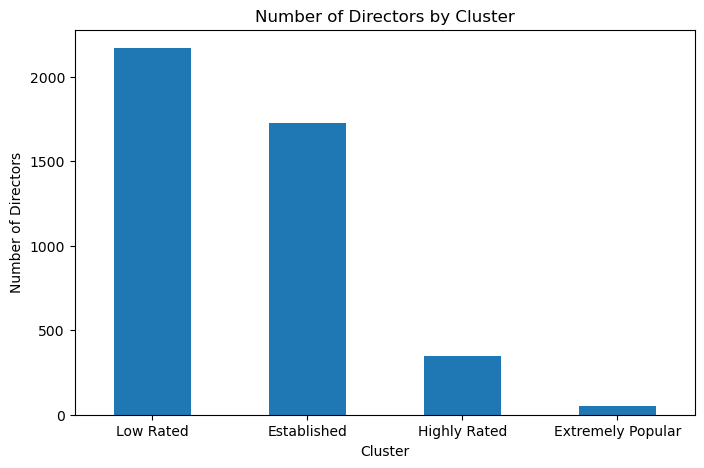

In [54]:
plot_data = director_summary.copy()
plot_data.index = plot_data.index.map(cluster_labels)

plt.figure(figsize=(8, 5))

plot_data['count'].plot(
    kind='bar'
)

plt.title('Number of Directors by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Directors')
plt.xticks(rotation=0)

plt.show()

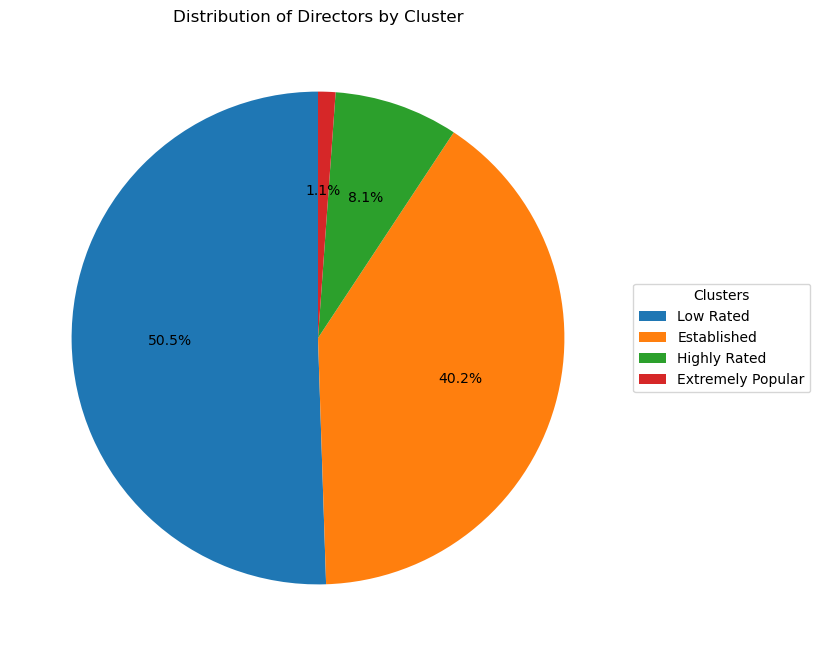

In [55]:
plt.figure(figsize=(8, 8))

plot_data['count'].plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    labels=None
)

plt.title('Distribution of Directors by Cluster')
plt.ylabel('')

plt.legend(
    labels=plot_data.index,
    title='Clusters',
    loc='center left',
    bbox_to_anchor=(1, 0.5)
)

plt.show()

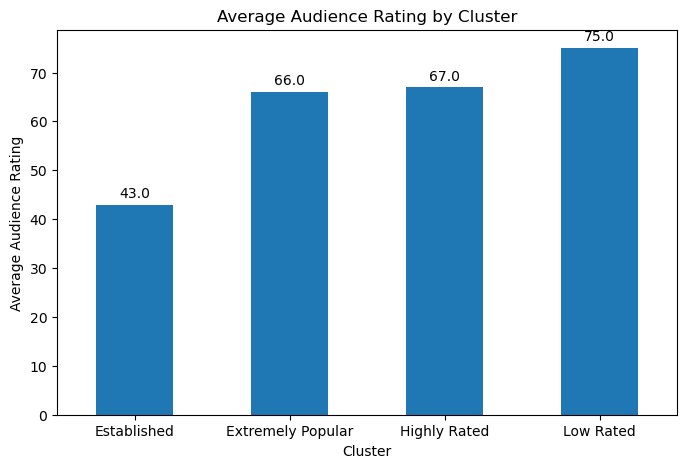

In [56]:
plot_data = plot_data.sort_values('rating_mean')

plt.figure(figsize=(8, 5))

ax = plot_data['rating_mean'].plot(
    kind='bar'
)

plt.title('Average Audience Rating by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average Audience Rating')
plt.xticks(rotation=0)

# Add values above the bars
ax.bar_label(
    ax.containers[0],
    fmt='%.1f',
    padding=3
)

plt.show()

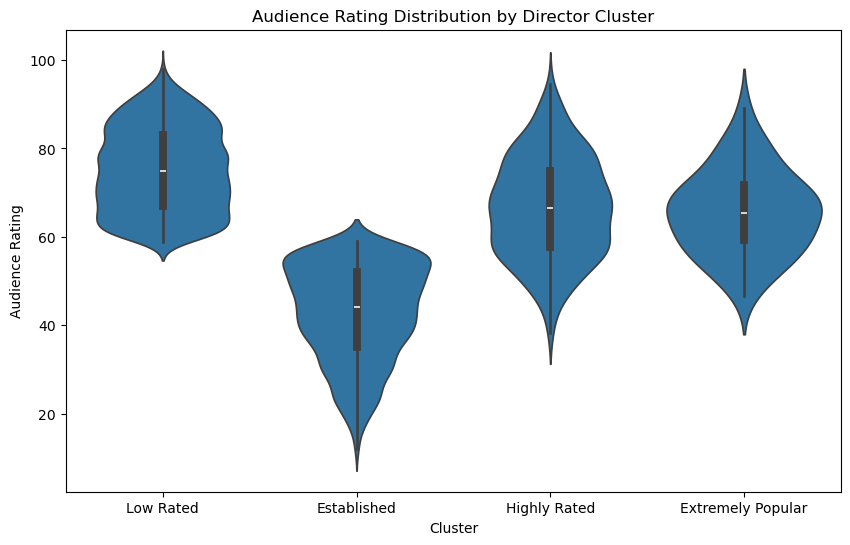

In [57]:
# Create a copy
plot_data = director_clusters.copy()

# Add cluster labels
plot_data['cluster_label'] = plot_data['cluster'].map(
    cluster_labels
)

plt.figure(figsize=(10, 6))

sns.violinplot(
    data=plot_data,
    x='cluster_label',
    y='audience_rating'
)

plt.title('Audience Rating Distribution by Director Cluster')
plt.xlabel('Cluster')
plt.ylabel('Audience Rating')

plt.show()

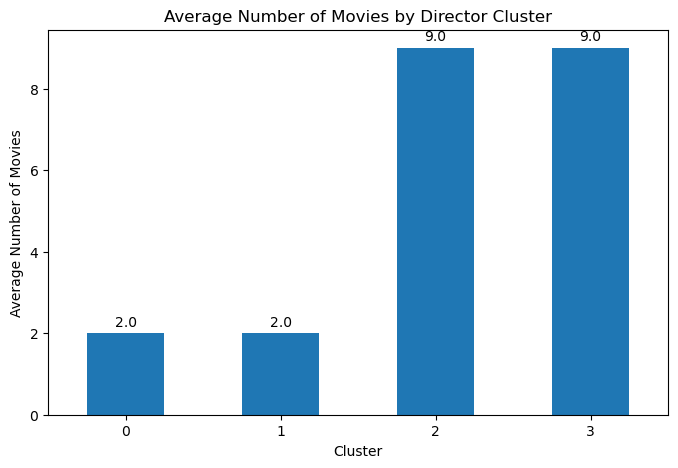

In [58]:
plot_data = director_summary.sort_values('movies_mean')

plt.figure(figsize=(8, 5))

ax = plot_data['movies_mean'].plot(
    kind='bar'
)

plt.title('Average Number of Movies by Director Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average Number of Movies')
plt.xticks(rotation=0)

ax.bar_label(
    ax.containers[0],
    fmt='%.1f',
    padding=3
)

plt.show()

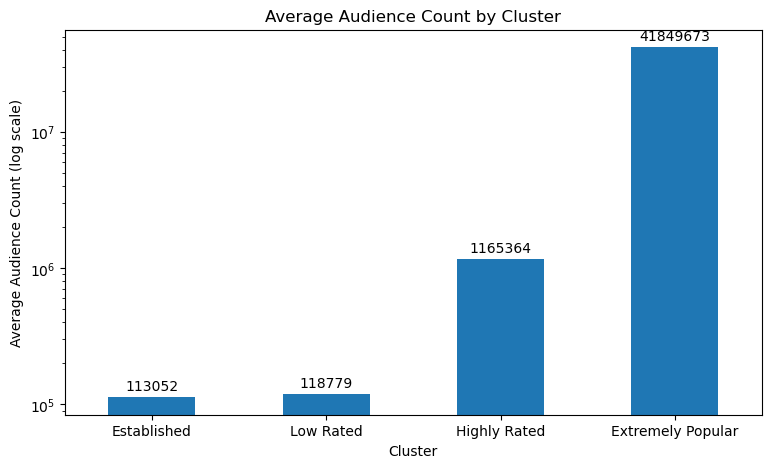

In [59]:
plot_data = director_summary.copy()

plot_data['cluster_label'] = plot_data.index.map(cluster_labels)
plot_data = plot_data.sort_values('audience_mean')

plt.figure(figsize=(9, 5))

ax = plot_data.set_index('cluster_label')['audience_mean'].plot(
    kind='bar'
)

plt.yscale('log')

plt.title('Average Audience Count by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average Audience Count (log scale)')
plt.xticks(rotation=0)

ax.bar_label(
    ax.containers[0],
    fmt='%.0f',
    padding=3
)

plt.show()

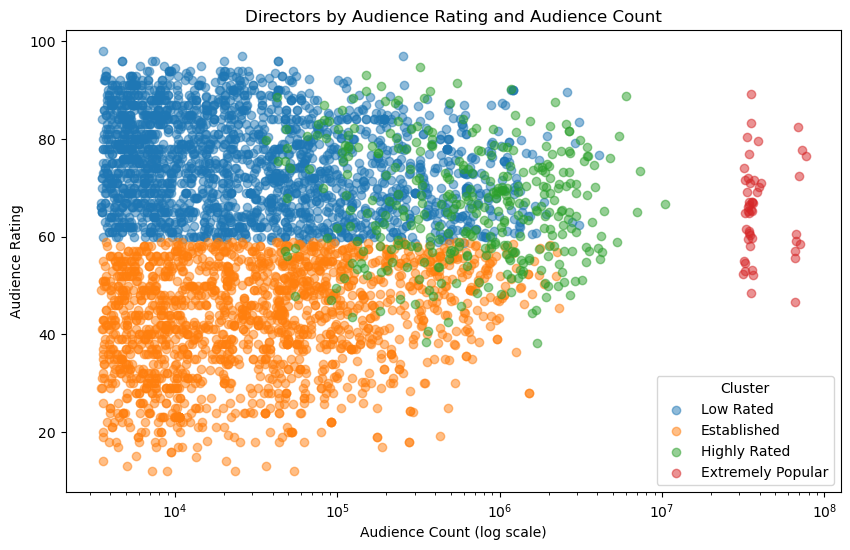

In [60]:
plt.figure(figsize=(10, 6))

for cluster in sorted(director_clusters['cluster'].unique()):

    cluster_data = director_clusters[
        director_clusters['cluster'] == cluster
    ]

    plt.scatter(
        cluster_data['audience_count'],
        cluster_data['audience_rating'],
        label=cluster_labels[cluster],
        alpha=0.5
    )

plt.xscale('log')

plt.title('Directors by Audience Rating and Audience Count')
plt.xlabel('Audience Count (log scale)')
plt.ylabel('Audience Rating')
plt.legend(title='Cluster')

plt.show()

## Author Clusters

K-Means was used to group authors based on three variables:

- **Audience Rating:** weighted average audience rating across their movies.
- **Audience Count:** total number of audience ratings accumulated by their movies.
- **Movie Count:** number of unique movies associated with each author.

Before creating the clusters, movies with fewer than or equal to **10,000 audience ratings** were excluded. This was done to focus the analysis on movies with a more substantial level of audience engagement.

The four clusters were interpreted based on their overall profile across these three dimensions:

| Cluster | Label | Main characteristic |
|---|---|---|
| 0 | **Highly Rated** | High audience rating with relatively low movie output |
| 1 | **Established** | Larger filmography and substantial audience reach |
| 2 | **Extremely Popular** | Extremely high audience engagement |
| 3 | **Low Rated** | Low audience rating and relatively low movie output |

### Cluster 0 – Highly Rated

This is the largest cluster, containing **2,917 authors**, and has the highest average audience rating, at **77**. Ratings range from **61 to 97**.

Authors in this cluster have an average audience count of approximately **204K ratings** and are associated with an average of **1 movie**.

For example, Anthony Fingleton has an audience rating of **77**, an audience count of approximately **199K**, and is associated with **1 movie**.

This cluster is mainly characterized by **high audience ratings rather than a large filmography or exceptionally high audience reach**.

### Cluster 1 – Established

This cluster contains **459 authors** and is mainly distinguished by its larger number of movies.

Authors in this group are associated with an average of **7 movies** and have an average audience count of approximately **1.5 million ratings**. The average audience rating is **63**.

Amanda Silver is a representative example, with an audience rating of approximately **63**, an audience count of **1.7 million**, and **8 movies**.

Compared with the Highly Rated cluster, these authors have a substantially larger filmography and greater audience reach. This suggests a group of **more established authors with a broader body of work and considerable audience exposure**.

### Cluster 2 – Extremely Popular

This is the smallest cluster, containing only **96 authors**, but it stands out because of its exceptionally high audience engagement.

The average audience count is approximately **38.2 million ratings**, by far the highest among all clusters. Authors in this group have an average audience rating of **63** and are associated with an average of **6 movies**.

Karen McCullah Lutz is a representative example, with an audience rating of approximately **65**, an audience count of **35.6 million**, and **6 movies**.

This cluster represents authors whose work has achieved **extremely high levels of audience exposure**, making audience reach its defining characteristic rather than audience rating.

### Cluster 3 – Low Rated

This cluster contains **2,548 authors** and has the lowest average audience rating, at **45**. Ratings range from **10 to 61**.

Authors in this cluster have an average audience count of approximately **182K ratings** and are associated with an average of **1 movie**.

Joseph Kwong is a representative example, with an audience rating of **46**, an audience count of approximately **181K**, and **1 movie**.

This cluster is characterized by **low audience ratings combined with relatively low movie output and limited audience reach**.

In [61]:
show_all_cluster_examples(
    author_clusters
)


Cluster 0

Highest Audience Rating:


,authors,audience_rating,audience_count,movie_count,cluster
0,Lucio Fulci,60.397809,26216.0,3,0



Lowest Audience Rating:


,authors,audience_rating,audience_count,movie_count,cluster
0,Dave Parker,10.0,46861.0,1,0



Representative Example:


...

,authors,audience_rating,audience_count,movie_count,cluster
0,Age,97.0,239803.0,1,3



Lowest Audience Rating:


,authors,audience_rating,audience_count,movie_count,cluster
0,Susan Minot,60.390456,144554.0,2,3



Representative Example:


,authors,audience_rating,audience_count,movie_count,cluster
0,Bert V. Royal,77.0,129018.0,1,3


In [62]:
author_summary = cluster_summary(author_clusters)

author_summary

,count,rating_min,rating_max,rating_mean,audience_min,audience_max,audience_mean,movies_min,movies_max,movies_mean
cluster,,,,,,,,,,
0,3394,10,60,44,3503,2861897,128174,1,5,1
1,626,30,95,64,33322,8925004,1216319,5,37,8
2,96,31,87,62,31617771,74161069,38247293,1,25,7
3,4274,60,97,76,3513,4718467,136431,1,5,1


In [63]:
author_summary = cluster_summary(author_clusters)

cluster_labels_authors = {
    0: 'Low Rated',
    1: 'Extremely Popular',
    2: 'Established',
    3: 'Highly Rated'
}

author_summary['cluster_label'] = author_summary.index.map(
    cluster_labels_authors
)

author_summary = author_summary.reset_index()

author_summary = author_summary.rename(
    columns={'cluster': 'Cluster Number'}
)

# Move cluster label to the first column
cols = ['cluster_label', 'Cluster Number'] + [
    col for col in author_summary.columns
    if col not in ['cluster_label', 'Cluster Number']
]

author_summary = author_summary[cols]

author_summary

,cluster_label,Cluster Number,count,rating_min,rating_max,rating_mean,audience_min,audience_max,audience_mean,movies_min,movies_max,movies_mean
0,Low Rated,0,3394,10,60,44,3503,2861897,128174,1,5,1
1,Extremely Popular,1,626,30,95,64,33322,8925004,1216319,5,37,8
2,Established,2,96,31,87,62,31617771,74161069,38247293,1,25,7
3,Highly Rated,3,4274,60,97,76,3513,4718467,136431,1,5,1


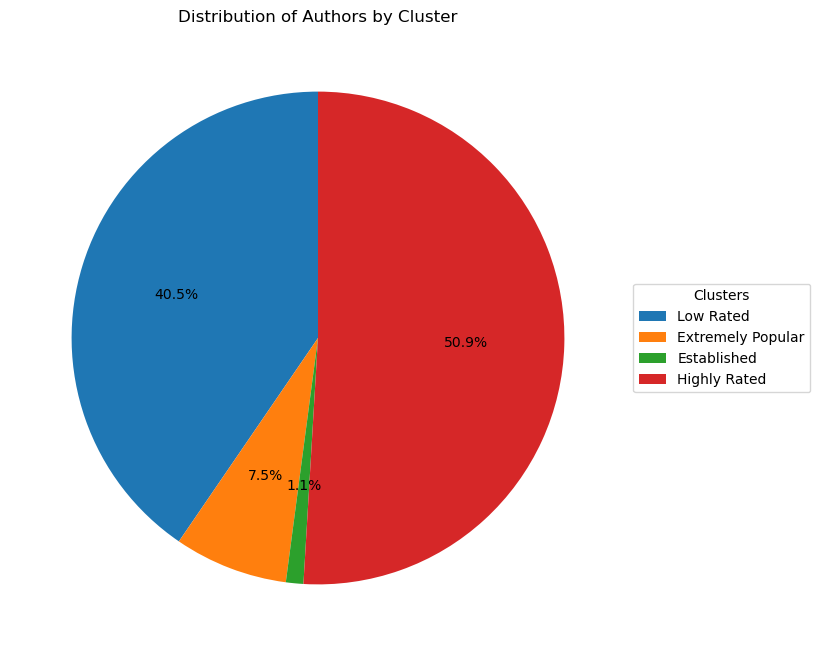

In [64]:
plot_data = author_summary.copy()

# Use cluster labels
plot_data['cluster_label'] = plot_data.index.map(
    cluster_labels_authors
)

# Use labels as index
plot_data = plot_data.set_index('cluster_label')

plt.figure(figsize=(8, 8))

plot_data['count'].plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    labels=None
)

plt.title('Distribution of Authors by Cluster')
plt.ylabel('')

plt.legend(
    labels=plot_data.index,
    title='Clusters',
    loc='center left',
    bbox_to_anchor=(1, 0.5)
)

plt.show()

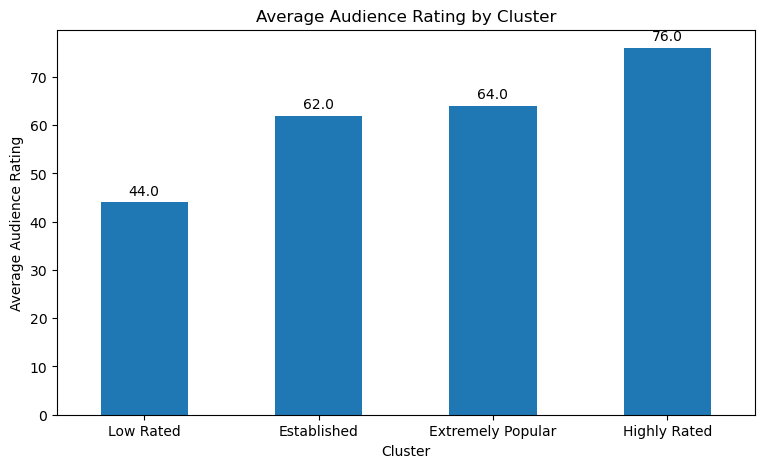

In [65]:
plot_data = author_summary.copy()

plot_data['cluster_label'] = plot_data.index.map(
    cluster_labels_authors
)

plot_data = plot_data.sort_values('rating_mean')

plt.figure(figsize=(9, 5))

ax = plot_data.set_index('cluster_label')['rating_mean'].plot(
    kind='bar'
)

plt.title('Average Audience Rating by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average Audience Rating')
plt.xticks(rotation=0)

ax.bar_label(
    ax.containers[0],
    fmt='%.1f',
    padding=3
)

plt.show()

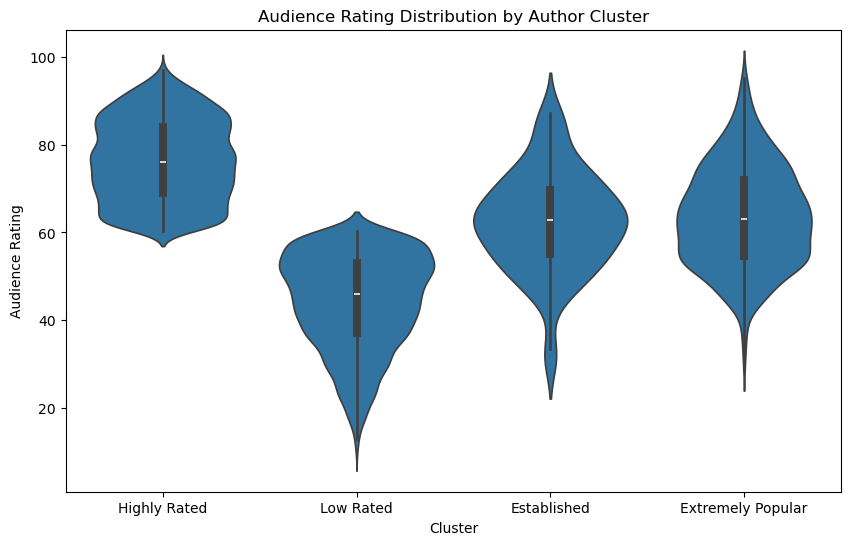

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a copy
plot_data = author_clusters.copy()

# Add cluster labels
plot_data['cluster_label'] = plot_data['cluster'].map(
    cluster_labels_authors
)

plt.figure(figsize=(10, 6))

sns.violinplot(
    data=plot_data,
    x='cluster_label',
    y='audience_rating'
)

plt.title('Audience Rating Distribution by Author Cluster')
plt.xlabel('Cluster')
plt.ylabel('Audience Rating')

plt.show()

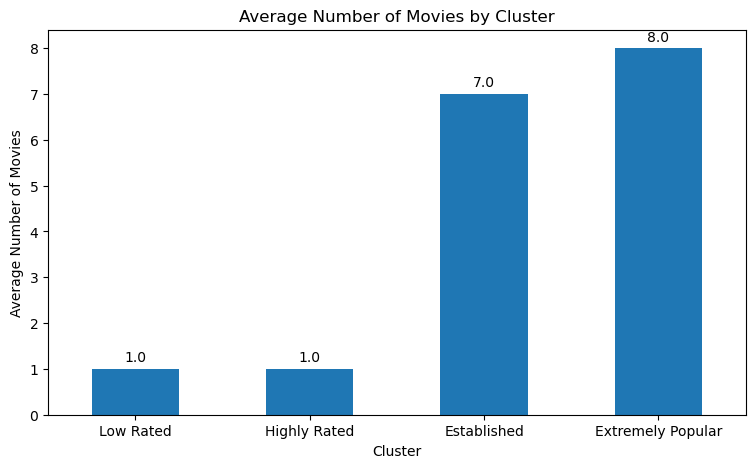

In [67]:
plot_data = author_summary.copy()

plot_data['cluster_label'] = plot_data.index.map(
    cluster_labels_authors
)

plot_data = plot_data.sort_values('movies_mean')

plt.figure(figsize=(9, 5))

ax = plot_data.set_index('cluster_label')['movies_mean'].plot(
    kind='bar'
)

plt.title('Average Number of Movies by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average Number of Movies')
plt.xticks(rotation=0)

ax.bar_label(
    ax.containers[0],
    fmt='%.1f',
    padding=3
)

plt.show()

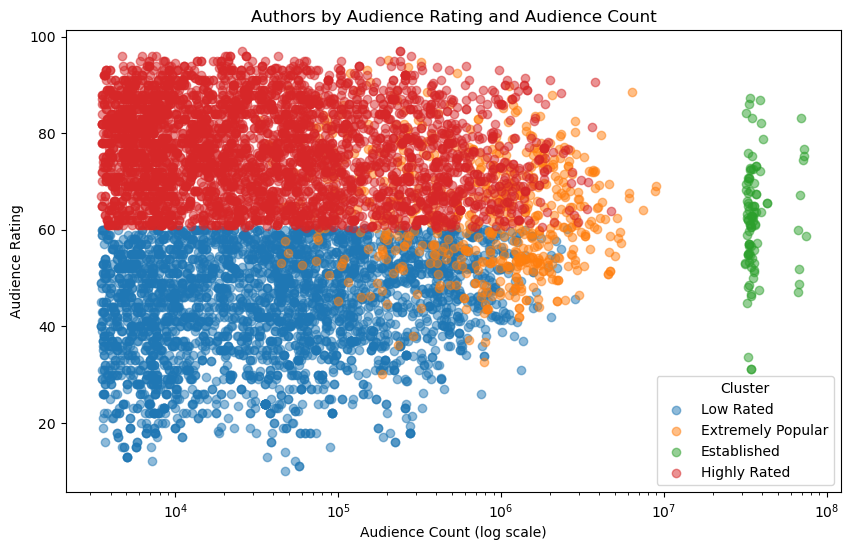

In [68]:
plt.figure(figsize=(10, 6))

for cluster in sorted(author_clusters['cluster'].unique()):

    cluster_data = author_clusters[
        author_clusters['cluster'] == cluster
    ]

    plt.scatter(
        cluster_data['audience_count'],
        cluster_data['audience_rating'],
        label=cluster_labels_authors[cluster],
        alpha=0.5
    )

plt.xscale('log')

plt.title('Authors by Audience Rating and Audience Count')
plt.xlabel('Audience Count (log scale)')
plt.ylabel('Audience Rating')

plt.legend(title='Cluster')

plt.show()

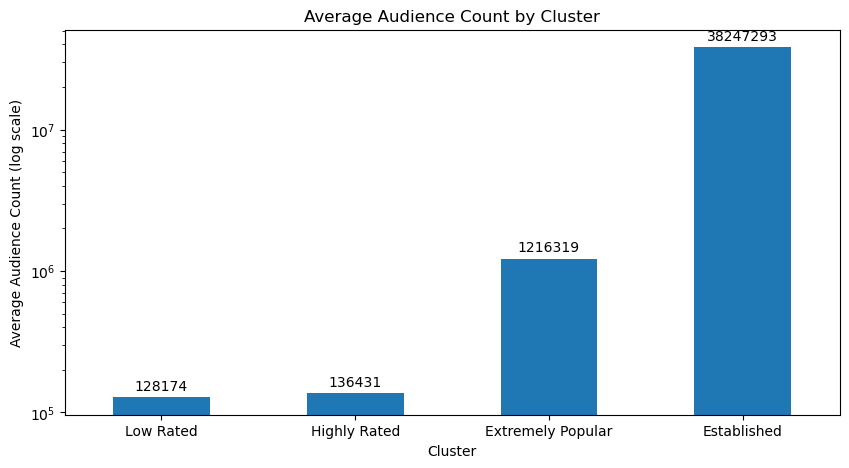

In [69]:
plot_data = author_summary.copy()

plot_data['cluster_label'] = plot_data.index.map(
    cluster_labels_authors
)

plot_data = plot_data.sort_values('audience_mean')

plt.figure(figsize=(10, 5))

ax = plot_data.set_index('cluster_label')['audience_mean'].plot(
    kind='bar'
)

plt.yscale('log')

plt.title('Average Audience Count by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average Audience Count (log scale)')
plt.xticks(rotation=0)

ax.bar_label(
    ax.containers[0],
    fmt='%.0f',
    padding=3
)

plt.show()

## Actor Clusters

K-Means was used to group actors based on three variables:

- **Audience Rating:** weighted average audience rating across their movies.
- **Audience Count:** total number of audience ratings accumulated by their movies.
- **Movie Count:** number of unique movies associated with each actor.

The four clusters were interpreted based on their overall profile across these three dimensions:

| Cluster | Label | Main characteristic |
|---|---|---|
| 0 | **Highly Rated** | Highest audience rating with relatively low audience reach |
| 1 | **Low Rated** | Lowest audience rating and limited audience reach |
| 2 | **Extremely Popular** | Extremely high audience engagement |
| 3 | **Many Movies** | Highest number of movies and substantial audience reach |

### Cluster 0 – Highly Rated

This cluster contains **111,398 actors** and has the highest average audience rating, at **76**. Ratings range from **60 to 100**.

Actors in this cluster have a relatively low audience reach, with an average of approximately **130.5K audience ratings**, and are associated with an average of **2 movies**.

This cluster is mainly characterized by **high audience ratings rather than high audience reach or a large number of movies**.

### Cluster 1 – Low Rated

This cluster contains **83,725 actors** and has the lowest average audience rating, at **45**. Ratings range from **0 to 61**.

The average audience count is approximately **108.9K ratings**, while actors in this cluster are associated with an average of **2 movies**.

This cluster represents actors whose movies have received **relatively low audience ratings and limited audience engagement**.

### Cluster 2 – Extremely Popular

This is the smallest cluster, containing only **2,475 actors**, but it stands out because of its exceptionally high audience engagement.

The average audience count is approximately **35.4 million ratings**, by far the highest among all clusters. Actors in this group have an average audience rating of **63** and are associated with an average of **8 movies**.

This cluster represents actors whose work has achieved **extremely high audience exposure**, even though their average audience rating is not the highest.

### Cluster 3 – Many Movies

This cluster contains **5,289 actors** and is mainly distinguished by the high number of movies associated with each actor.

Actors in this group are associated with an average of **18 movies**, compared with only **2 movies** in Clusters 0 and 1 and **8 movies** in Cluster 2.

The average audience rating is **62**, while the average audience count is approximately **1.58 million ratings**.

This suggests that this cluster represents actors with a **much larger number of movies and substantial audience reach**.

In [70]:
show_all_cluster_examples(
    actor_clusters
)


Cluster 0

Highest Audience Rating:


,actors,audience_rating,audience_count,movie_count,cluster
0,Drew Scheid,99.0,11821.0,1,0



Lowest Audience Rating:


,actors,audience_rating,audience_count,movie_count,cluster
0,Angelo Pagan,62.667008,280940.0,2,0



Representative Example:


...

,actors,audience_rating,audience_count,movie_count,cluster
0,Takashi Shimura,92.228028,299731.0,12,3



Lowest Audience Rating:


,actors,audience_rating,audience_count,movie_count,cluster
0,Rhys Coiro,38.278432,2030164.0,9,3



Representative Example:


,actors,audience_rating,audience_count,movie_count,cluster
0,Paul Reiser,61.457097,2205264.0,15,3


In [71]:
actor_summary = cluster_summary(
    actor_clusters
)

actor_summary

,count,rating_min,rating_max,rating_mean,audience_min,audience_max,audience_mean,movies_min,movies_max,movies_mean
cluster,,,,,,,,,,
0,79873,63,99,78,3511,6438681,173685,1,9,1
1,59049,10,64,47,3502,4948077,173163,1,9,2
2,2463,31,91,63,30984568,114729578,35416107,1,94,7
3,3639,38,92,62,49749,47694508,2189144,9,72,15


In [72]:
cluster_labels_actors = {
    0: 'Highly Rated',
    1: 'Low Rated',
    2: 'Extremely Popular',
    3: 'Established'
}

In [73]:
actor_summary = cluster_summary(actor_clusters)

actor_summary['cluster_label'] = actor_summary.index.map(
    cluster_labels_actors
)

actor_summary = actor_summary.reset_index()

actor_summary = actor_summary.rename(
    columns={'cluster': 'Cluster Number'}
)

cols = ['cluster_label', 'Cluster Number'] + [
    col for col in actor_summary.columns
    if col not in ['cluster_label', 'Cluster Number']
]

actor_summary = actor_summary[cols]

actor_summary

,cluster_label,Cluster Number,count,rating_min,rating_max,rating_mean,audience_min,audience_max,audience_mean,movies_min,movies_max,movies_mean
0,Highly Rated,0,79873,63,99,78,3511,6438681,173685,1,9,1
1,Low Rated,1,59049,10,64,47,3502,4948077,173163,1,9,2
2,Extremely Popular,2,2463,31,91,63,30984568,114729578,35416107,1,94,7
3,Established,3,3639,38,92,62,49749,47694508,2189144,9,72,15


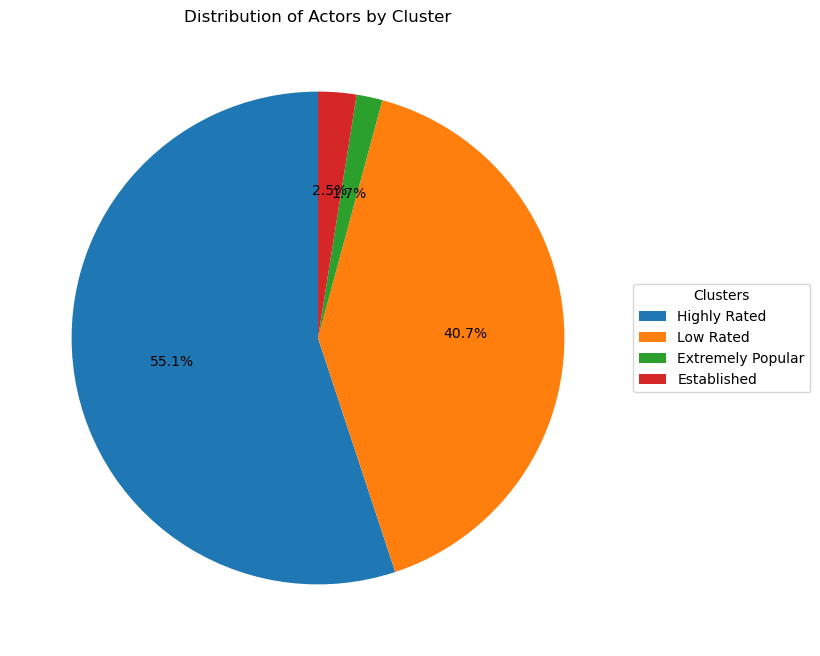

In [74]:
plot_data = actor_summary.copy()

plot_data = plot_data.set_index('cluster_label')

plt.figure(figsize=(8, 8))

plot_data['count'].plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    labels=None
)

plt.title('Distribution of Actors by Cluster')
plt.ylabel('')

plt.legend(
    labels=plot_data.index,
    title='Clusters',
    loc='center left',
    bbox_to_anchor=(1, 0.5)
)

plt.show()

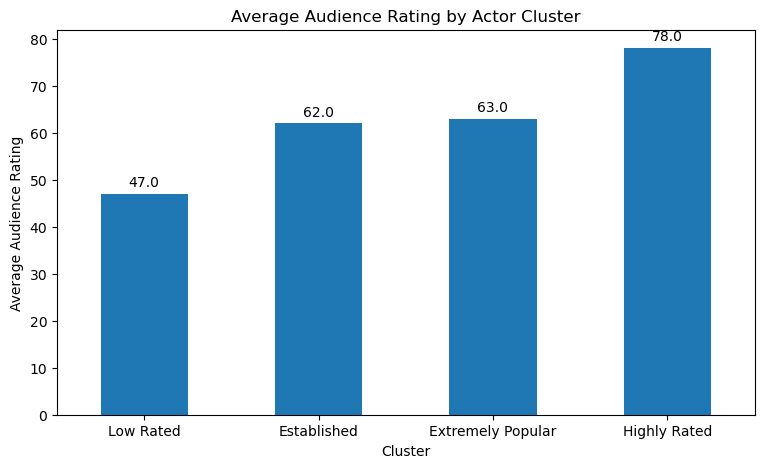

In [75]:
plot_data = actor_summary.copy()

plot_data = plot_data.sort_values('rating_mean')

plt.figure(figsize=(9, 5))

ax = plot_data.set_index('cluster_label')['rating_mean'].plot(
    kind='bar'
)

plt.title('Average Audience Rating by Actor Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average Audience Rating')
plt.xticks(rotation=0)

ax.bar_label(
    ax.containers[0],
    fmt='%.1f',
    padding=3
)

plt.show()

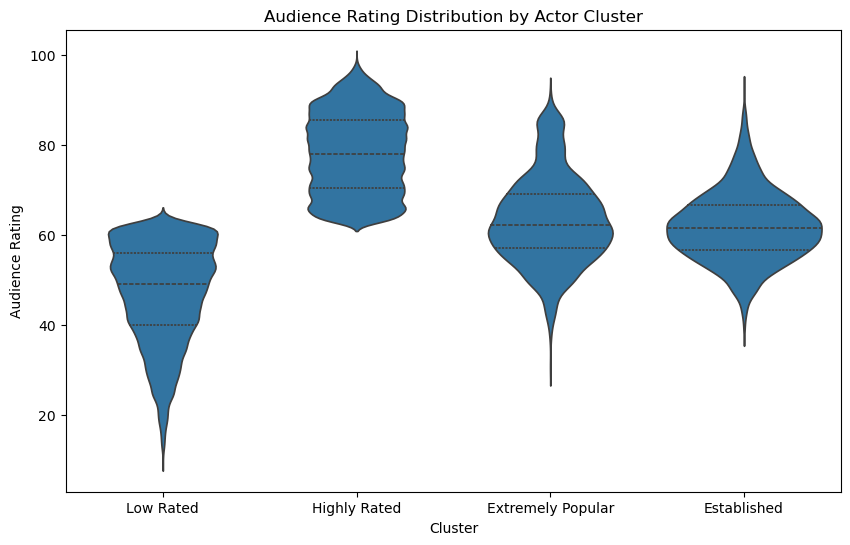

In [76]:
plot_data = actor_clusters.copy()

plot_data['cluster_label'] = plot_data['cluster'].map(
    cluster_labels_actors
)

plt.figure(figsize=(10, 6))

sns.violinplot(
    data=plot_data,
    x='cluster_label',
    y='audience_rating',
    inner='quartile'
)

plt.title('Audience Rating Distribution by Actor Cluster')
plt.xlabel('Cluster')
plt.ylabel('Audience Rating')

plt.show()

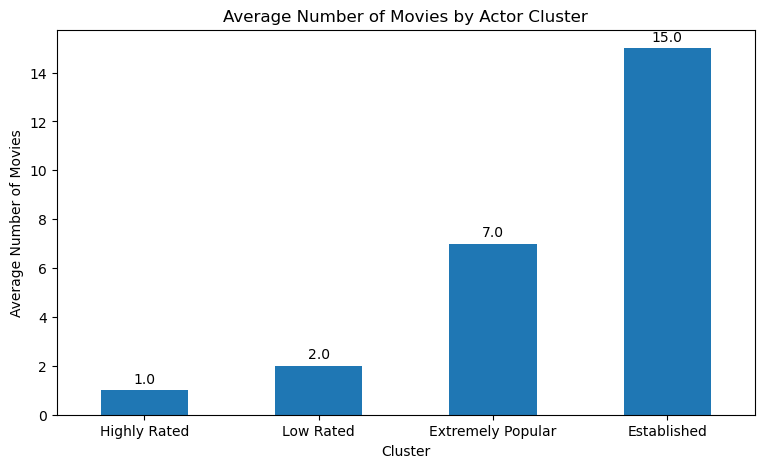

In [77]:
plot_data = actor_summary.copy()

plot_data = plot_data.sort_values('movies_mean')

plt.figure(figsize=(9, 5))

ax = plot_data.set_index('cluster_label')['movies_mean'].plot(
    kind='bar'
)

plt.title('Average Number of Movies by Actor Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average Number of Movies')
plt.xticks(rotation=0)

ax.bar_label(
    ax.containers[0],
    fmt='%.1f',
    padding=3
)

plt.show()

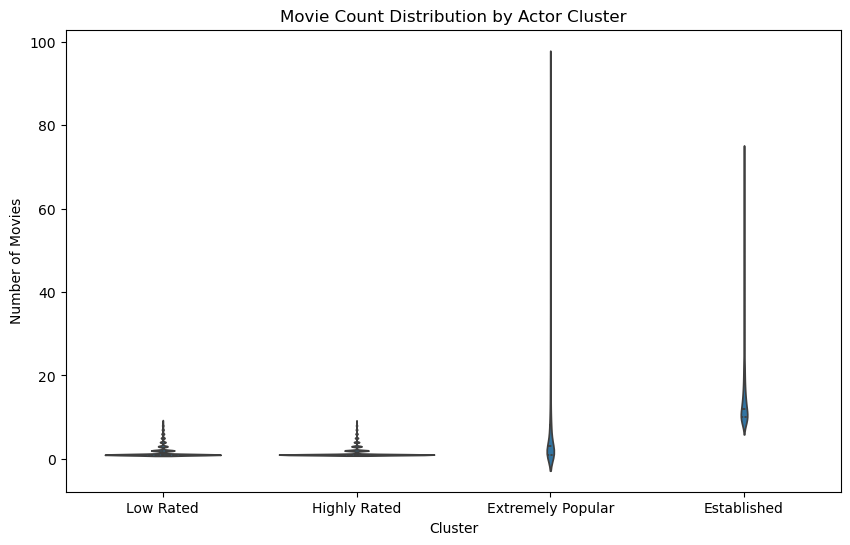

In [78]:
plot_data = actor_clusters.copy()

plot_data['cluster_label'] = plot_data['cluster'].map(
    cluster_labels_actors
)

plt.figure(figsize=(10, 6))

sns.violinplot(
    data=plot_data,
    x='cluster_label',
    y='movie_count',
    inner='quartile'
)

plt.title('Movie Count Distribution by Actor Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Movies')

plt.show()

In [79]:
plot_data['movie_count_log'] = np.log1p(
    plot_data['movie_count']
)

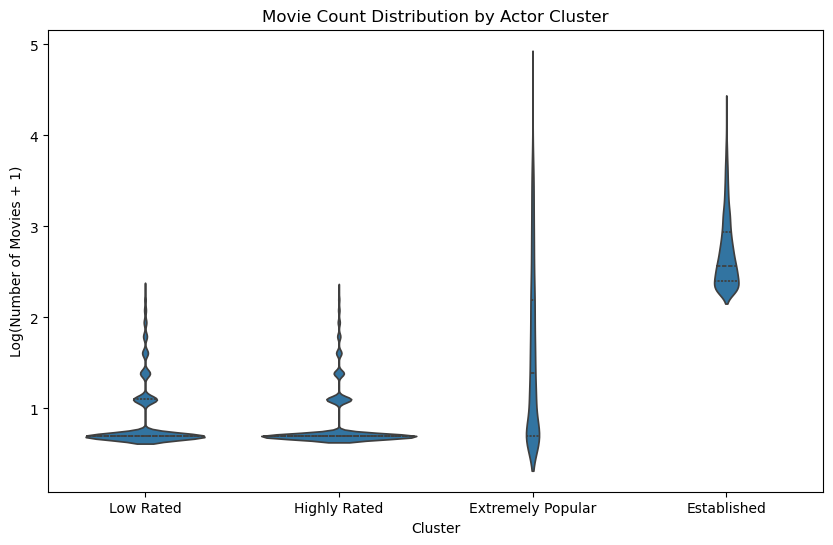

In [80]:
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=plot_data,
    x='cluster_label',
    y='movie_count_log',
    inner='quartile'
)

plt.title('Movie Count Distribution by Actor Cluster')
plt.xlabel('Cluster')
plt.ylabel('Log(Number of Movies + 1)')

plt.show()

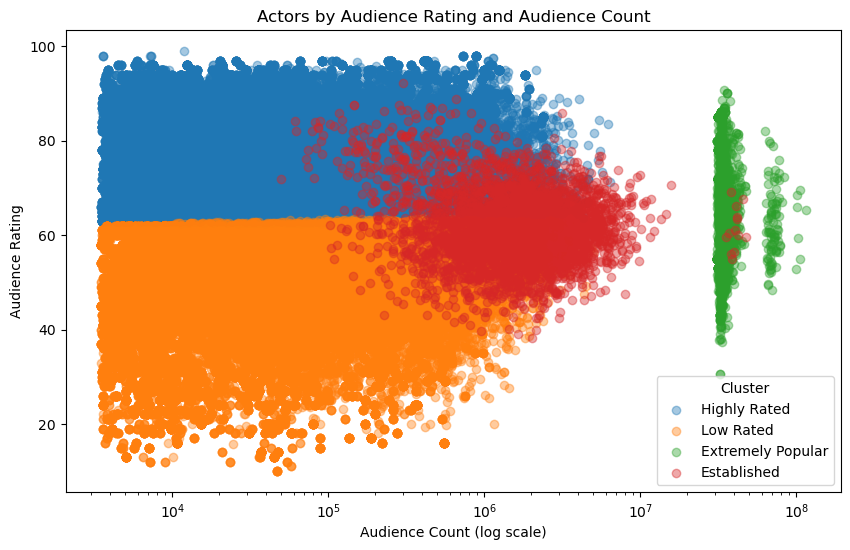

In [81]:
plt.figure(figsize=(10, 6))

for cluster in sorted(actor_clusters['cluster'].unique()):

    cluster_data = actor_clusters[
        actor_clusters['cluster'] == cluster
    ]

    plt.scatter(
        cluster_data['audience_count'],
        cluster_data['audience_rating'],
        label=cluster_labels_actors[cluster],
        alpha=0.4
    )

plt.xscale('log')

plt.title('Actors by Audience Rating and Audience Count')
plt.xlabel('Audience Count (log scale)')
plt.ylabel('Audience Rating')

plt.legend(title='Cluster')

plt.show()

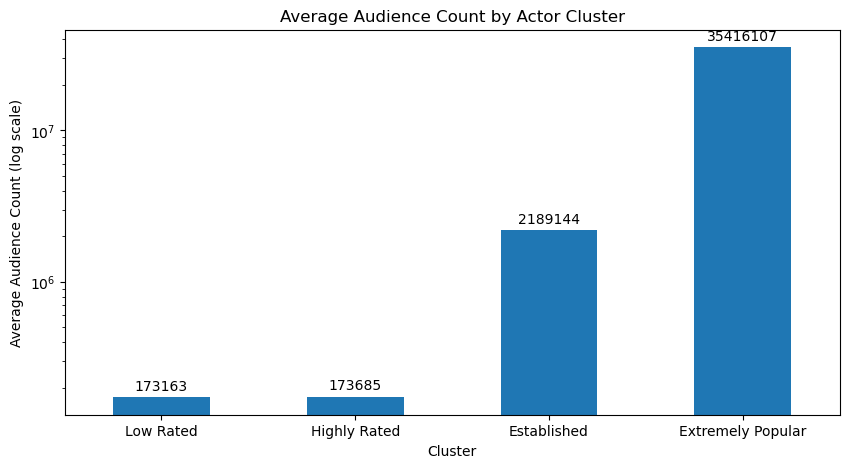

In [82]:
plot_data = actor_summary.copy()

plot_data = plot_data.sort_values('audience_mean')

plt.figure(figsize=(10, 5))

ax = plot_data.set_index('cluster_label')['audience_mean'].plot(
    kind='bar'
)

plt.yscale('log')

plt.title('Average Audience Count by Actor Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average Audience Count (log scale)')
plt.xticks(rotation=0)

ax.bar_label(
    ax.containers[0],
    fmt='%.0f',
    padding=3
)

plt.show()

## Production Company Clusters

K-Means was used to group production companies based on three variables:

- **Audience Rating:** weighted average audience rating across their movies.
- **Audience Count:** total number of audience ratings accumulated by their movies.
- **Movie Count:** number of unique movies associated with each production company.

Before creating the clusters, movies with fewer than or equal to **10,000 audience ratings** were excluded. This was done to focus the analysis on movies with a more substantial level of audience engagement.

The four clusters were interpreted based on their overall profile across these three dimensions:

| Cluster | Label | Main characteristic |
|---|---|---|
| 0 | **Established** | Large filmography and substantial audience reach |
| 1 | **Low Rated** | Low audience rating and relatively limited movie output |
| 2 | **Extremely Popular** | Extremely high audience engagement and very large movie output |
| 3 | **Highly Rated** | Highest audience rating with relatively low movie output |

### Cluster 0 – Established

This cluster contains **28 production companies** and is mainly distinguished by its large movie output and substantial audience reach.

Production companies in this group are associated with an average of **87 movies** and have an average audience count of approximately **34.8 million ratings**. The average audience rating is **64**.

Focus Features is a representative example, with an audience rating of approximately **65**, an audience count of approximately **8.9 million ratings**, and **98 movies**.

This suggests that the cluster represents **established production companies with a broad filmography and considerable audience exposure**.

### Cluster 1 – Low Rated

This cluster contains **304 production companies** and has the lowest average audience rating, at **47**. Ratings range from **12 to 63**.

Production companies in this group are associated with an average of **4 movies** and have an average audience count of approximately **649K ratings**.

Walt Disney Television Animation is a representative example, with an audience rating of approximately **48**, an audience count of approximately **496K ratings**, and **4 movies**.

This cluster is characterized by **low audience ratings combined with relatively limited movie output and audience reach**.

### Cluster 2 – Extremely Popular

This is the smallest cluster, containing only **4 production companies**, but it stands out because of its exceptionally high audience engagement and movie output.

Production companies in this group are associated with an average of **355 movies** and have an average audience count of approximately **286.6 million ratings**, by far the highest among all clusters.

The average audience rating is **63**, which is similar to the Established cluster.

Universal Pictures is a representative example, with an audience rating of approximately **63**, an audience count of approximately **335.9 million ratings**, and **364 movies**.

This cluster represents **extremely large production companies whose movies have achieved exceptionally high levels of audience exposure**.

### Cluster 3 – Highly Rated

This is the largest cluster, containing **404 production companies**, and has the highest average audience rating, at **78**. Ratings range from **63 to 97**.

Production companies in this cluster are associated with an average of only **2 movies** and have an average audience count of approximately **395K ratings**.

Lionsgate Releasing is a representative example, with an audience rating of approximately **78**, an audience count of approximately **115K ratings**, and **2 movies**.

This cluster is mainly characterized by **high audience ratings rather than a large filmography or exceptionally high audience reach**.

In [83]:
show_all_cluster_examples(
    production_clusters
)


Cluster 0

Highest Audience Rating:


,production_company,audience_rating,audience_count,movie_count,cluster
0,Affirm Films,98.0,7217.0,1,0



Lowest Audience Rating:


,production_company,audience_rating,audience_count,movie_count,cluster
0,Tribeca Film,61.818792,43083.0,6,0



Representative Example:


...

,production_company,audience_rating,audience_count,movie_count,cluster
0,United Artists,77.2198,38183332.0,85,3



Lowest Audience Rating:


,production_company,audience_rating,audience_count,movie_count,cluster
0,MCA Universal Home Video,57.367799,7768236.0,133,3



Representative Example:


,production_company,audience_rating,audience_count,movie_count,cluster
0,Twentieth Century Fox Home Entertainment,62.480564,7040143.0,134,3


In [84]:
production_summary = cluster_summary(production_clusters)

production_summary

,count,rating_min,rating_max,rating_mean,audience_min,audience_max,audience_mean,movies_min,movies_max,movies_mean
cluster,,,,,,,,,,
0,720,62,98,78,3545,48245864,309983,1,68,3
1,4,61,65,63,211002175,336120880,286541581,367,447,404
2,485,12,62,46,3502,67873010,542580,1,65,4
3,26,57,77,64,2495854,160582101,32936845,55,282,131


In [85]:
cluster_labels_production = {
    0: 'Highly Rated',
    1: 'Low Rated',
    2: 'Extremely Popular',
    3: 'Established'
}

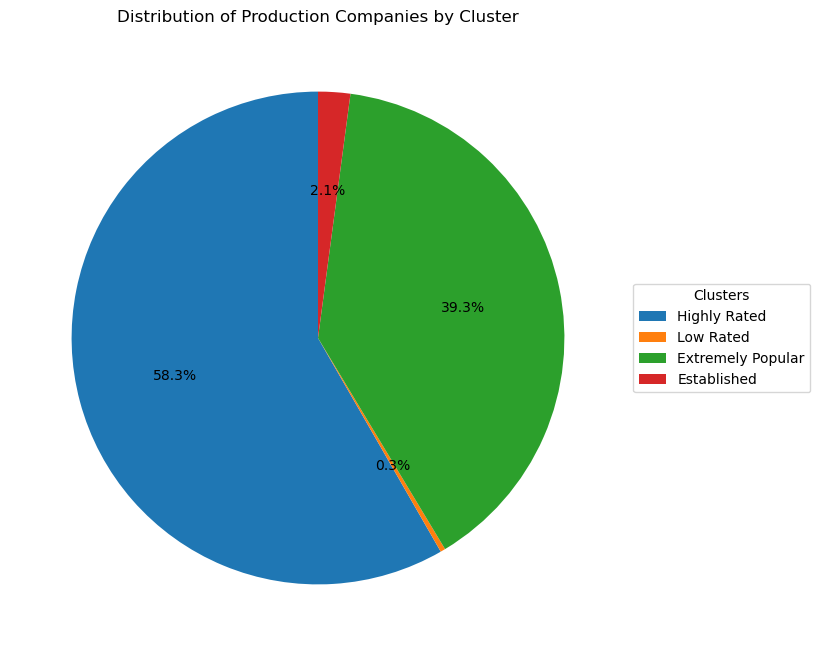

In [86]:
plot_data = production_summary.copy()

plot_data['cluster_label'] = plot_data.index.map(
    cluster_labels_production
)

plot_data = plot_data.set_index('cluster_label')

plt.figure(figsize=(8, 8))

plot_data['count'].plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    labels=None
)

plt.title('Distribution of Production Companies by Cluster')
plt.ylabel('')

plt.legend(
    labels=plot_data.index,
    title='Clusters',
    loc='center left',
    bbox_to_anchor=(1, 0.5)
)

plt.show()

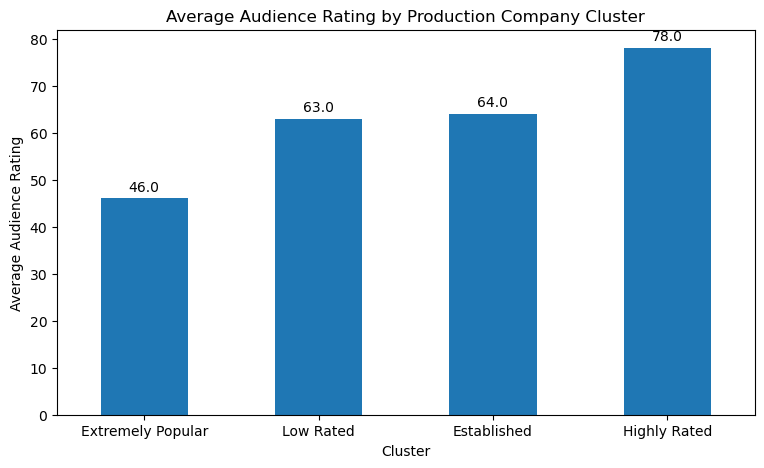

In [87]:
plot_data = production_summary.copy()

plot_data['cluster_label'] = plot_data.index.map(
    cluster_labels_production
)

plot_data = plot_data.sort_values('rating_mean')

plt.figure(figsize=(9, 5))

ax = plot_data.set_index('cluster_label')['rating_mean'].plot(
    kind='bar'
)

plt.title('Average Audience Rating by Production Company Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average Audience Rating')
plt.xticks(rotation=0)

ax.bar_label(
    ax.containers[0],
    fmt='%.1f',
    padding=3
)

plt.show()

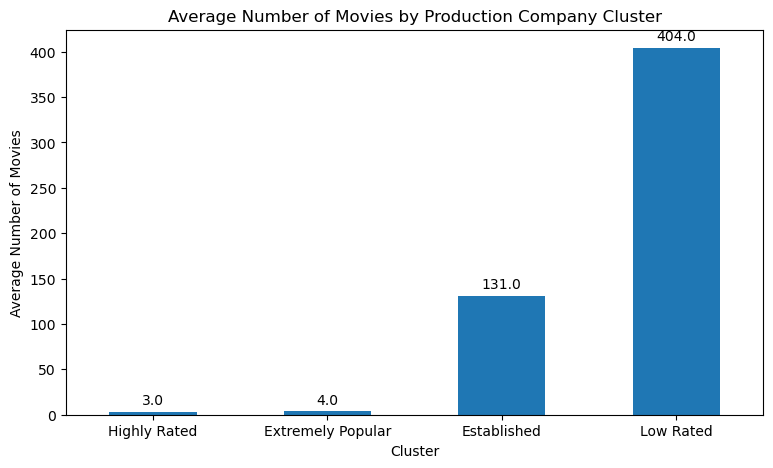

In [88]:
plot_data = production_summary.copy()

plot_data['cluster_label'] = plot_data.index.map(
    cluster_labels_production
)

plot_data = plot_data.sort_values('movies_mean')

plt.figure(figsize=(9, 5))

ax = plot_data.set_index('cluster_label')['movies_mean'].plot(
    kind='bar'
)

plt.title('Average Number of Movies by Production Company Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average Number of Movies')
plt.xticks(rotation=0)

ax.bar_label(
    ax.containers[0],
    fmt='%.1f',
    padding=3
)

plt.show()

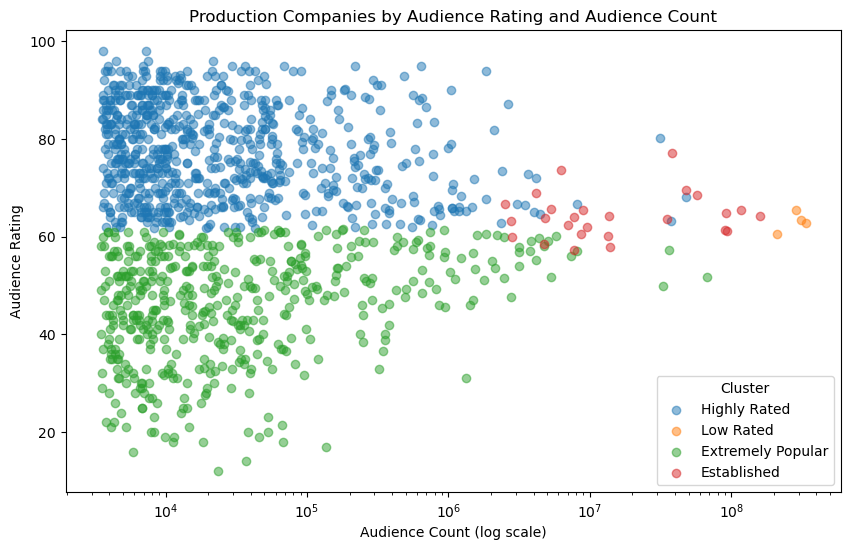

In [89]:
plt.figure(figsize=(10, 6))

for cluster in sorted(production_clusters['cluster'].unique()):

    cluster_data = production_clusters[
        production_clusters['cluster'] == cluster
    ]

    plt.scatter(
        cluster_data['audience_count'],
        cluster_data['audience_rating'],
        label=cluster_labels_production[cluster],
        alpha=0.5
    )

plt.xscale('log')

plt.title(
    'Production Companies by Audience Rating and Audience Count'
)
plt.xlabel('Audience Count (log scale)')
plt.ylabel('Audience Rating')

plt.legend(title='Cluster')

plt.show()

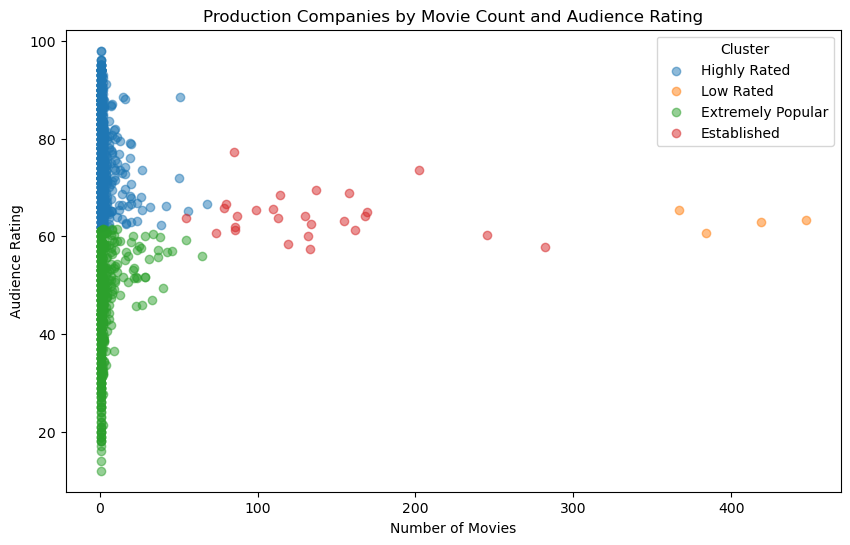

In [90]:
plt.figure(figsize=(10, 6))

for cluster in sorted(production_clusters['cluster'].unique()):

    cluster_data = production_clusters[
        production_clusters['cluster'] == cluster
    ]

    plt.scatter(
        cluster_data['movie_count'],
        cluster_data['audience_rating'],
        label=cluster_labels_production[cluster],
        alpha=0.5
    )

plt.title('Production Companies by Movie Count and Audience Rating')
plt.xlabel('Number of Movies')
plt.ylabel('Audience Rating')

plt.legend(title='Cluster')

plt.show()

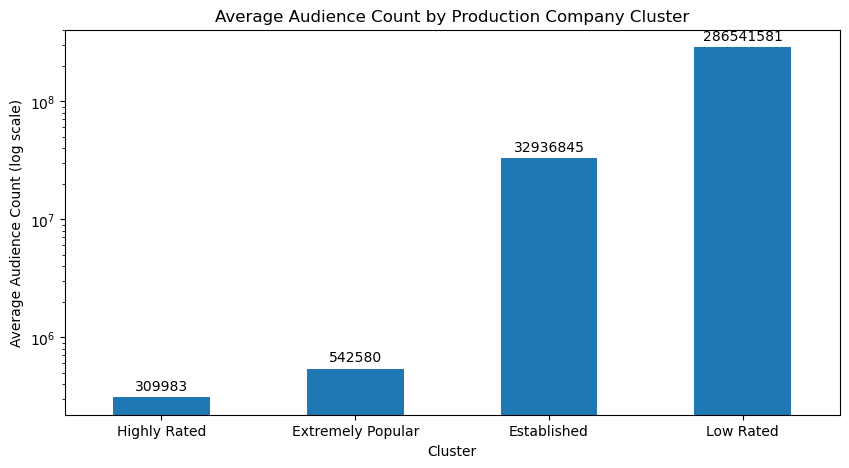

In [91]:
plot_data = production_summary.copy()

plot_data['cluster_label'] = plot_data.index.map(
    cluster_labels_production
)

plot_data = plot_data.sort_values('audience_mean')

plt.figure(figsize=(10, 5))

ax = plot_data.set_index('cluster_label')['audience_mean'].plot(
    kind='bar'
)

plt.yscale('log')

plt.title('Average Audience Count by Production Company Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average Audience Count (log scale)')
plt.xticks(rotation=0)

ax.bar_label(
    ax.containers[0],
    fmt='%.0f',
    padding=3
)

plt.show()

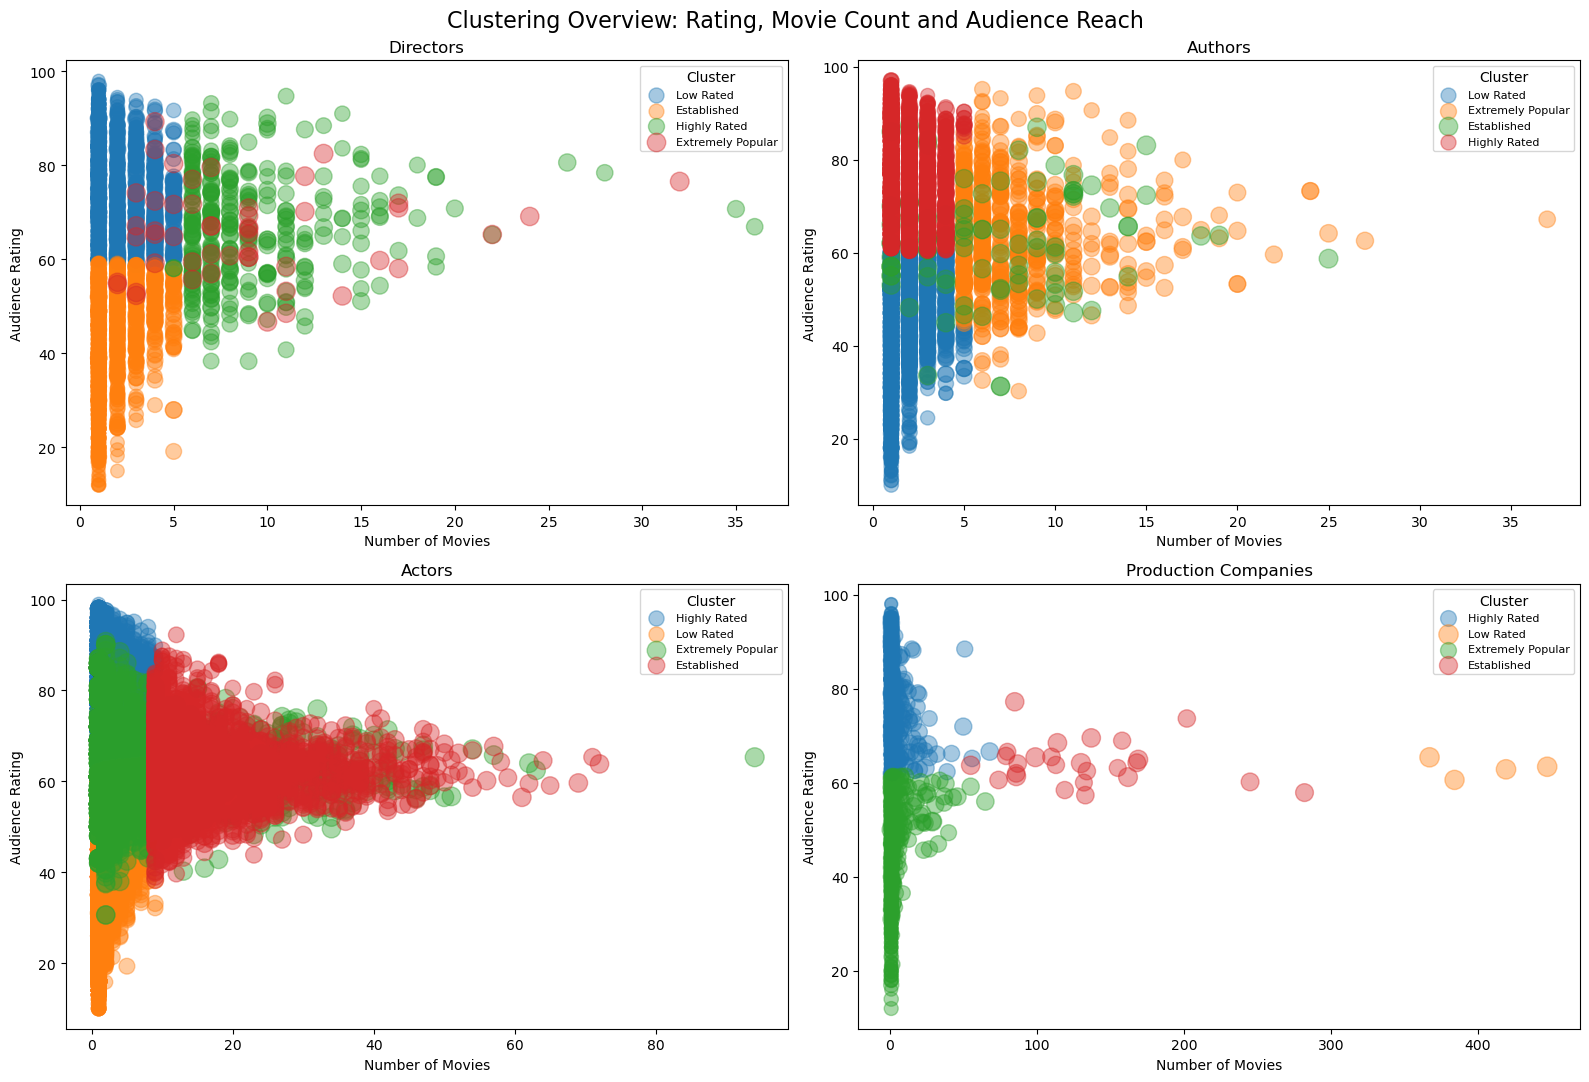

In [92]:
import matplotlib.pyplot as plt
import numpy as np

# Dataframes
cluster_data = {
    'Directors': (director_clusters, cluster_labels),
    'Authors': (author_clusters, cluster_labels_authors),
    'Actors': (actor_clusters, cluster_labels_actors),
    'Production Companies': (
        production_clusters,
        cluster_labels_production
    )
}

fig, axes = plt.subplots(
    2, 2,
    figsize=(16, 11)
)

axes = axes.flatten()

for ax, (name, (df, labels)) in zip(
    axes,
    cluster_data.items()
):

    for cluster in sorted(df['cluster'].unique()):

        cluster_df = df[
            df['cluster'] == cluster
        ]

        # Scale bubble size
        sizes = (
            np.log1p(cluster_df['audience_count']) * 10
        )

        ax.scatter(
            cluster_df['movie_count'],
            cluster_df['audience_rating'],
            s=sizes,
            alpha=0.4,
            label=labels[cluster]
        )

    ax.set_title(name)
    ax.set_xlabel('Number of Movies')
    ax.set_ylabel('Audience Rating')

    ax.legend(
        title='Cluster',
        fontsize=8
    )

plt.suptitle(
    'Clustering Overview: Rating, Movie Count and Audience Reach',
    fontsize=16
)

plt.tight_layout()

plt.show()

In [93]:
# Create summary data

summaries = {
    'Directors': director_summary,
    'Authors': author_summary,
    'Actors': actor_summary,
    'Production Companies': production_summary
}

labels_dict = {
    'Directors': cluster_labels,
    'Authors': cluster_labels_authors,
    'Actors': cluster_labels_actors,
    'Production Companies': cluster_labels_production
}

heatmap_data = []

for entity, summary in summaries.items():

    for cluster in summary.index:

        heatmap_data.append({
            'Entity': entity,
            'Cluster': labels_dict[entity][cluster],
            'Audience Rating': summary.loc[
                cluster, 'rating_mean'
            ],
            'Audience Count': summary.loc[
                cluster, 'audience_mean'
            ],
            'Movie Count': summary.loc[
                cluster, 'movies_mean'
            ]
        })

heatmap_df = pd.DataFrame(heatmap_data)

heatmap_df

,Entity,Cluster,Audience Rating,Audience Count,Movie Count
0,Directors,Low Rated,75,118779,2
1,Directors,Established,43,113052,2
2,Directors,Highly Rated,67,1165364,9
3,Directors,Extremely Popular,66,41849673,9
4,Authors,Low Rated,44,128174,1
5,Authors,Extremely Popular,64,1216319,8
6,Authors,Established,62,38247293,7
7,Authors,Highly Rated,76,136431,1
8,Actors,Highly Rated,78,173685,1
9,Actors,Low Rated,47,173163,2


In [94]:
# Normalize variables between 0 and 1

features = [
    'Audience Rating',
    'Audience Count',
    'Movie Count'
]

heatmap_scaled = heatmap_df.copy()

for feature in features:

    min_value = heatmap_scaled[feature].min()
    max_value = heatmap_scaled[feature].max()

    heatmap_scaled[feature] = (
        (heatmap_scaled[feature] - min_value)
        / (max_value - min_value)
    )

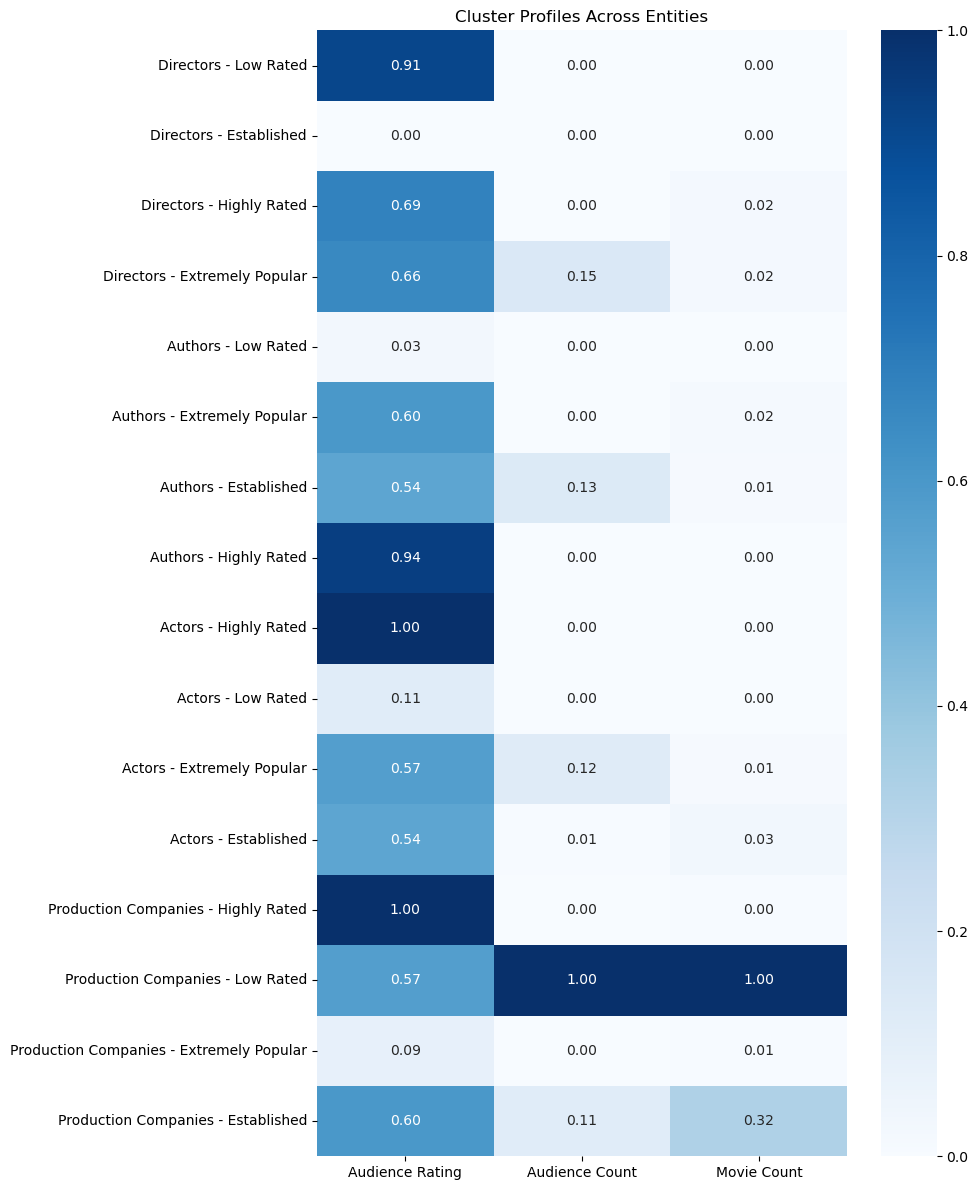

In [95]:
# Create row labels

heatmap_scaled['Label'] = (
    heatmap_scaled['Entity']
    + ' - '
    + heatmap_scaled['Cluster']
)

heatmap_matrix = heatmap_scaled.set_index(
    'Label'
)[features]

plt.figure(figsize=(10, 12))

sns.heatmap(
    heatmap_matrix,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    vmin=0,
    vmax=1
)

plt.title(
    'Cluster Profiles Across Entities'
)

plt.xlabel('')
plt.ylabel('')

plt.tight_layout()

plt.show()

In [96]:
filtered_rt_df.head()

,movie_title,directors,authors,actors,original_release_date,streaming_release_date,runtime,production_company,tomatometer_status,tomatometer_rating,audience_rating,audience_count,content_group,main_genre
0,Titanic,James Cameron,James Cameron,"Leonardo DiCaprio, Kate Winslet, Billy Zane, K...",1997-12-19,2014-06-01,195.0,Paramount Pictures,Fresh,89.0,69.0,35797635.0,Teen,Drama
1,The Lord of the Rings: The Return of the King,Peter Jackson,"Fran Walsh, Philippa Boyens, Peter Jackson","Elijah Wood, Sean Astin, Ian McKellen, Andy Se...",2003-12-17,2010-04-06,200.0,New Line Cinema,Fresh,93.0,86.0,34679773.0,Teen,Action
2,Spider-Man,Sam Raimi,David Koepp,"Tobey Maguire, Kirsten Dunst, Willem Dafoe, Ja...",2002-05-03,2013-04-25,116.0,Columbia Pictures,Fresh,90.0,67.0,34297354.0,Teen,Action
3,Shrek 2,"Conrad Vernon, Andrew Adamson, Kelly Asbury","Joe Stillman, David N. Weiss, J. David Stern, ...","Mike Myers, John Cleese, Jonathan Ross, Jennif...",2004-05-19,2015-11-25,92.0,Dreamworks,Fresh,89.0,69.0,34232524.0,Family,Comedy
4,Harry Potter and the Goblet of Fire,Mike Newell,Steve Kloves,"Daniel Radcliffe, Rupert Grint, Emma Watson, R...",2005-11-18,2008-01-01,157.0,Warner Bros. Pictures,Fresh,88.0,74.0,34153607.0,Teen,Action


# Add Cluster columns

In [97]:
def assign_cluster_by_rating(df, cluster_df, column):
    
    # Dictionary with entity -> audience_rating and cluster
    cluster_info = cluster_df[
        ['audience_rating', 'cluster']
    ].to_dict('index')
    
    def get_main_cluster(value):
        
        if pd.isna(value):
            return np.nan
        
        # Split multiple entities
        entities = [
            entity.strip()
            for entity in value.split(',')
        ]
        
        # Keep only entities that exist in the cluster dataframe
        entities = [
            entity for entity in entities
            if entity in cluster_info
        ]
        
        if not entities:
            return np.nan
        
        # Select entity with highest audience rating
        main_entity = max(
            entities,
            key=lambda entity: cluster_info[entity]['audience_rating']
        )
        
        return cluster_info[main_entity]['cluster']
    
    df[f'{column}_cluster'] = df[column].apply(
        get_main_cluster
    )
    
    return df

In [98]:
filtered_rt_df = assign_cluster_by_rating(
    filtered_rt_df,
    director_clusters,
    'directors'
)

filtered_rt_df= assign_cluster_by_rating(
    filtered_rt_df,
    author_clusters,
    'authors'
)

filtered_rt_df = assign_cluster_by_rating(
    filtered_rt_df,
    actor_clusters,
    'actors'
)

filtered_rt_df = assign_cluster_by_rating(
    filtered_rt_df,
    production_clusters,
    'production_company'
)

In [99]:
filtered_rt_df.head()

,movie_title,directors,authors,actors,original_release_date,streaming_release_date,runtime,production_company,tomatometer_status,tomatometer_rating,audience_rating,audience_count,content_group,main_genre,directors_cluster,authors_cluster,actors_cluster,production_company_cluster
0,Titanic,James Cameron,James Cameron,"Leonardo DiCaprio, Kate Winslet, Billy Zane, K...",1997-12-19,2014-06-01,195.0,Paramount Pictures,Fresh,89.0,69.0,35797635.0,Teen,Drama,3.0,2.0,2.0,1.0
1,The Lord of the Rings: The Return of the King,Peter Jackson,"Fran Walsh, Philippa Boyens, Peter Jackson","Elijah Wood, Sean Astin, Ian McKellen, Andy Se...",2003-12-17,2010-04-06,200.0,New Line Cinema,Fresh,93.0,86.0,34679773.0,Teen,Action,3.0,2.0,2.0,3.0
2,Spider-Man,Sam Raimi,David Koepp,"Tobey Maguire, Kirsten Dunst, Willem Dafoe, Ja...",2002-05-03,2013-04-25,116.0,Columbia Pictures,Fresh,90.0,67.0,34297354.0,Teen,Action,3.0,2.0,2.0,3.0
3,Shrek 2,"Conrad Vernon, Andrew Adamson, Kelly Asbury","Joe Stillman, David N. Weiss, J. David Stern, ...","Mike Myers, John Cleese, Jonathan Ross, Jennif...",2004-05-19,2015-11-25,92.0,Dreamworks,Fresh,89.0,69.0,34232524.0,Family,Comedy,3.0,2.0,2.0,0.0
4,Harry Potter and the Goblet of Fire,Mike Newell,Steve Kloves,"Daniel Radcliffe, Rupert Grint, Emma Watson, R...",2005-11-18,2008-01-01,157.0,Warner Bros. Pictures,Fresh,88.0,74.0,34153607.0,Teen,Action,3.0,2.0,2.0,1.0


## EDA

In [100]:
filtered_rt_df.shape

(8935, 18)

In [101]:
filtered_rt_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8935 entries, 0 to 8934
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   movie_title                 8935 non-null   object 
 1   directors                   8855 non-null   object 
 2   authors                     8538 non-null   object 
 3   actors                      8900 non-null   object 
 4   original_release_date       8808 non-null   object 
 5   streaming_release_date      8877 non-null   object 
 6   runtime                     8894 non-null   float64
 7   production_company          8889 non-null   object 
 8   tomatometer_status          8935 non-null   object 
 9   tomatometer_rating          8935 non-null   float64
 10  audience_rating             8935 non-null   float64
 11  audience_count              8935 non-null   float64
 12  content_group               8935 non-null   object 
 13  main_genre                  8935 non-n

In [102]:
filtered_rt_df.describe().T

,count,mean,std,min,25%,50%,75%,max
runtime,8894.0,105.973465,1.918162e+01,8.0,93.0,103.0,115.0,255.0
tomatometer_rating,8935.0,59.163290,2.850867e+01,0.0,36.0,64.0,85.0,100.0
audience_rating,8935.0,63.341466,1.985792e+01,10.0,48.0,66.0,80.0,99.0
audience_count,8935.0,278644.040515,2.454573e+06,3502.0,7757.5,22090.0,76267.5,35797635.0
directors_cluster,8855.0,1.066742,9.304693e-01,0.0,0.0,1.0,2.0,3.0
authors_cluster,8538.0,1.635512,1.242606e+00,0.0,1.0,1.0,3.0,3.0
actors_cluster,8900.0,0.654607,1.180538e+00,0.0,0.0,0.0,0.0,3.0
production_company_cluster,8889.0,1.735966,1.192504e+00,0.0,1.0,2.0,3.0,3.0


In [103]:
filtered_rt_df.isna().sum().sort_values(ascending=False)

authors                       397
authors_cluster               397
original_release_date         127
directors                      80
directors_cluster              80
streaming_release_date         58
production_company_cluster     46
production_company             46
runtime                        41
actors                         35
actors_cluster                 35
main_genre                      0
movie_title                     0
content_group                   0
audience_count                  0
audience_rating                 0
tomatometer_status              0
tomatometer_rating              0
dtype: int64

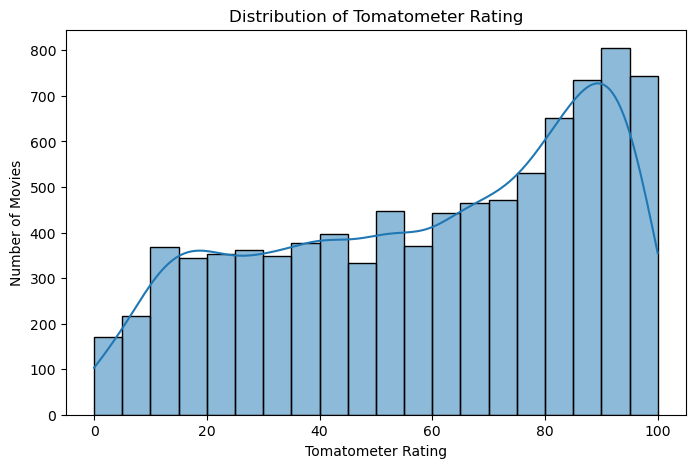

In [104]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=filtered_rt_df,
    x='tomatometer_rating',
    bins=20,
    kde=True
)

plt.title('Distribution of Tomatometer Rating')
plt.xlabel('Tomatometer Rating')
plt.ylabel('Number of Movies')

plt.show()

In [105]:
filtered_rt_df['tomatometer_status'].value_counts(normalize=True) * 100

tomatometer_status
Fresh     54.224958
Rotten    45.775042
Name: proportion, dtype: float64

In [106]:
cluster_cols = [
    'directors_cluster',
    'authors_cluster',
    'actors_cluster',
    'production_company_cluster'
]

numeric_df = (
    filtered_rt_df
    .select_dtypes(include='number')
    .drop(columns=cluster_cols, errors='ignore')
)

In [107]:
numeric_df.columns

Index(['runtime', 'tomatometer_rating', 'audience_rating', 'audience_count'], dtype='object')

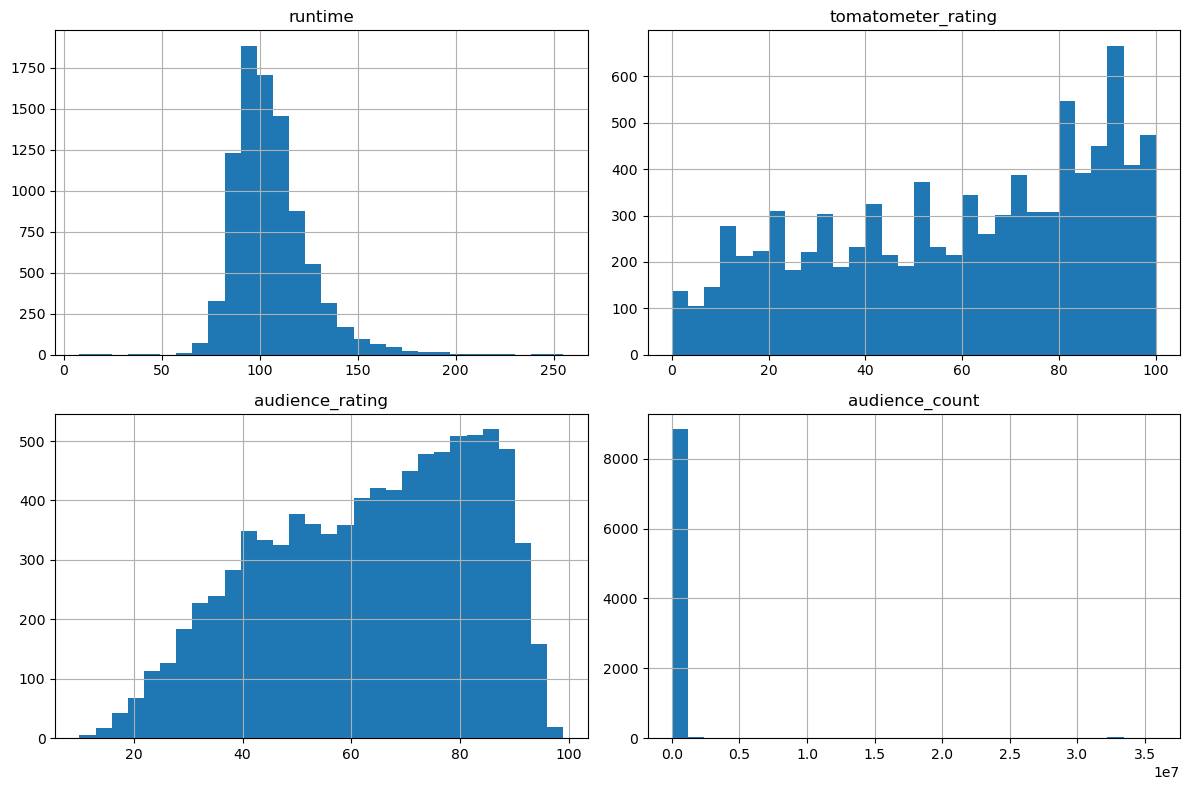

In [108]:
numeric_df.hist(
    figsize=(12,8),
    bins=30
)

plt.tight_layout()
plt.show()

In [109]:
filtered_rt_df['target'] = (
    filtered_rt_df['tomatometer_status'] == 'Fresh'
).astype(int)

In [110]:
cluster_cols = [
    'directors_cluster',
    'authors_cluster',
    'actors_cluster',
    'production_company_cluster'
]

numeric_df = filtered_rt_df.select_dtypes(include='number').drop(
    columns=cluster_cols,
    errors='ignore'
)

correlations = (
    numeric_df.corr()['target']
    .drop('target')
    .sort_values(ascending=False)
)

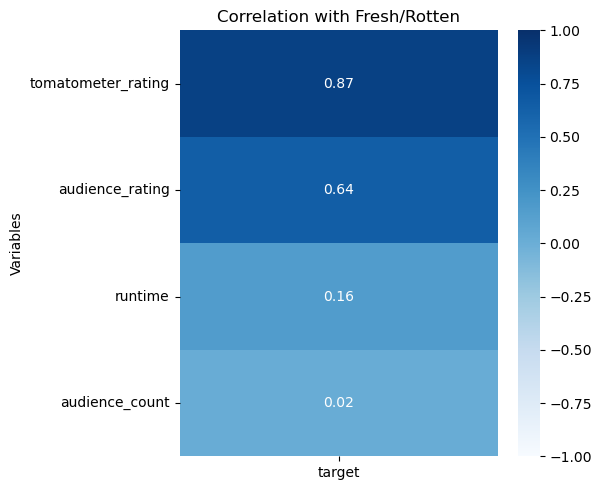

In [111]:
plt.figure(figsize=(6,5))

sns.heatmap(
    correlations.to_frame(),
    annot=True,
    fmt='.2f',
    cmap='Blues',
    vmin=-1,
    vmax=1
)

plt.title('Correlation with Fresh/Rotten')
plt.xlabel('')
plt.ylabel('Variables')

plt.tight_layout()
plt.show()

In [112]:
filtered_rt_df['content_group'].value_counts()

content_group
Adult      3884
Teen       2254
Family     1911
Unknown     886
Name: count, dtype: int64

In [113]:
filtered_rt_df.groupby(
    'content_group'
)['tomatometer_status'].value_counts().unstack(fill_value=0)

tomatometer_status,Fresh,Rotten
content_group,,
Adult,2067,1817
Family,1102,809
Teen,910,1344
Unknown,766,120


In [114]:
content_status = pd.crosstab(
    filtered_rt_df['content_group'],
    filtered_rt_df['tomatometer_status'],
    normalize='index'
) * 100

content_status.round(2)

tomatometer_status,Fresh,Rotten
content_group,,
Adult,53.22,46.78
Family,57.67,42.33
Teen,40.37,59.63
Unknown,86.46,13.54


<Figure size 800x500 with 0 Axes>

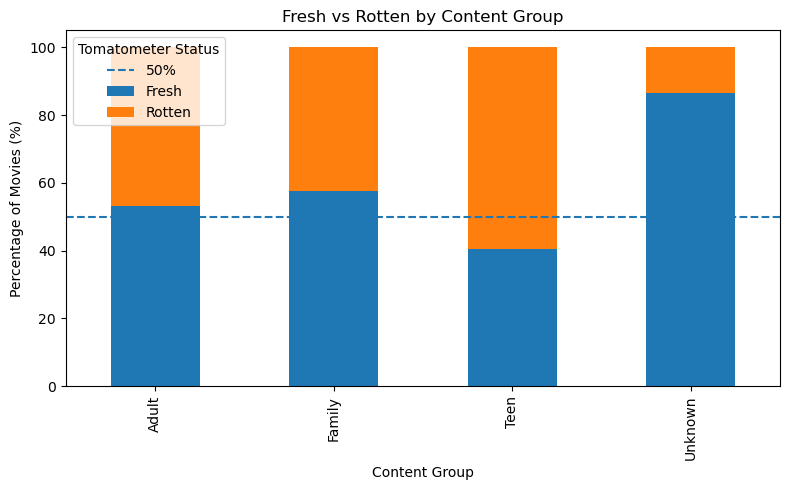

In [115]:
plt.figure(figsize=(8,5))

ax = content_status.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.axhline(
    50,
    linestyle='--',
    linewidth=1.5,
    label='50%'
)

plt.title('Fresh vs Rotten by Content Group')
plt.xlabel('Content Group')
plt.ylabel('Percentage of Movies (%)')
plt.legend(title='Tomatometer Status')

plt.tight_layout()
plt.show()

In [116]:
genre_status = (
    pd.crosstab(
        filtered_rt_df['main_genre'],
        filtered_rt_df['tomatometer_status']
    )
)

genre_status['Total'] = genre_status.sum(axis=1)

genre_status['Fresh %'] = (
    genre_status['Fresh'] / genre_status['Total'] * 100
)

genre_status['Rotten %'] = (
    genre_status['Rotten'] / genre_status['Total'] * 100
)

genre_status = genre_status[
    ['Total', 'Fresh', 'Fresh %', 'Rotten', 'Rotten %']
].sort_values('Fresh %', ascending=False)

genre_status.round(2)

tomatometer_status,Total,Fresh,Fresh %,Rotten,Rotten %
main_genre,,,,,
Documentary,257,245,95.33,12,4.67
Other,7,5,71.43,2,28.57
Drama,2709,1810,66.81,899,33.19
Romance,20,10,50.00,10,50.00
Comedy,2788,1350,48.42,1438,51.58
Action,2423,1154,47.63,1269,52.37
Sci-Fi,178,83,46.63,95,53.37
Family,71,33,46.48,38,53.52
Suspense,87,37,42.53,50,57.47


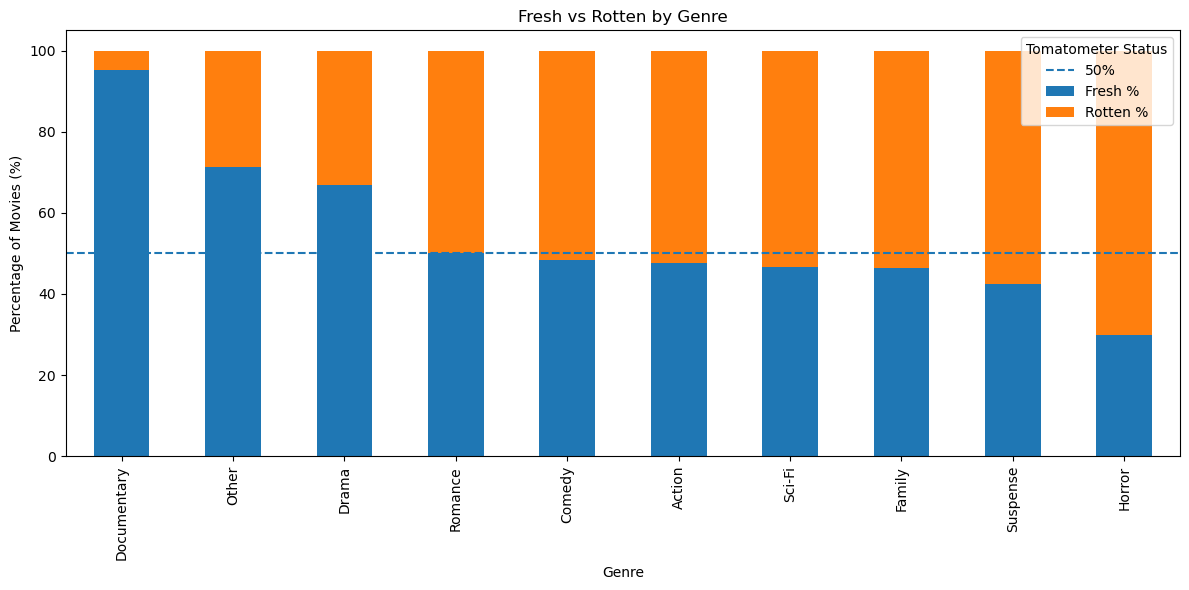

In [117]:
genre_status[['Fresh %', 'Rotten %']].plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)
plt.axhline(
    50,
    linestyle='--',
    linewidth=1.5,
    label='50%'
)

plt.title('Fresh vs Rotten by Genre')
plt.xlabel('Genre')
plt.ylabel('Percentage of Movies (%)')
plt.legend(title='Tomatometer Status')

plt.tight_layout()
plt.show()

In [118]:
#Algunos Generos influyen en que sea fresh o no. 

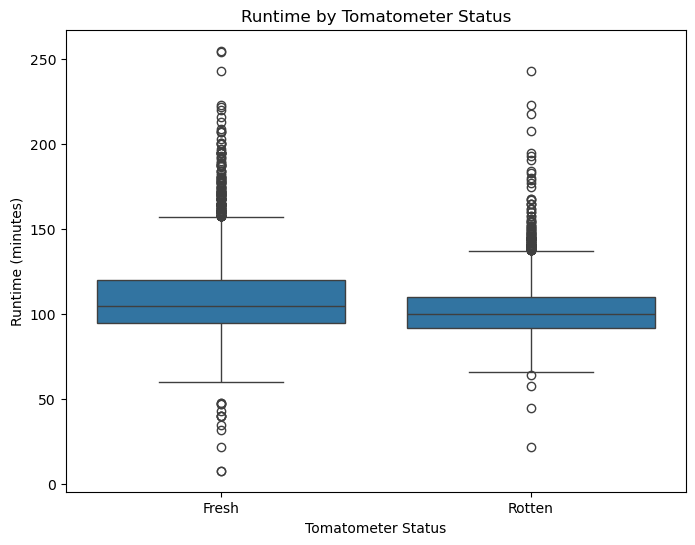

In [119]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=filtered_rt_df,
    x='tomatometer_status',
    y='runtime'
)

plt.title('Runtime by Tomatometer Status')
plt.xlabel('Tomatometer Status')
plt.ylabel('Runtime (minutes)')

plt.show()

In [120]:
# Create runtime deciles
filtered_rt_df['runtime_decile'] = pd.qcut(
    filtered_rt_df['runtime'],
    q=10,
    duplicates='drop'
)

# Calculate average rating, number of movies and average audience ratings
runtime_deciles = (
    filtered_rt_df
    .groupby('runtime_decile', observed=True)
    .agg(
        avg_rating=('tomatometer_rating', 'mean'),
        movie_count=('movie_title', 'count'),
        avg_audience_count=('audience_count', 'mean')
    )
    .reset_index()
)

# Format the table
runtime_deciles.style.format({
    'avg_rating': '{:.2f}',
    'movie_count': '{:,.0f}',
    'avg_audience_count': '{:,.0f}'
})

,runtime_decile,avg_rating,movie_count,avg_audience_count
0,"(7.999, 87.0]",57.19,959,"114,810"
1,"(87.0, 91.0]",51.42,891,"118,193"
2,"(91.0, 95.0]",52.46,953,"255,122"
3,"(95.0, 99.0]",53.98,942,"179,942"
4,"(99.0, 103.0]",56.99,870,"226,033"
5,"(103.0, 107.0]",57.79,811,"95,960"
6,"(107.0, 112.0]",60.55,856,"314,469"
7,"(112.0, 119.0]",61.94,896,"645,200"
8,"(119.0, 129.0]",67.79,839,"267,787"
9,"(129.0, 255.0]",72.81,877,"585,431"


In [121]:
runtime_status = (
    pd.crosstab(
        filtered_rt_df['runtime_decile'],
        filtered_rt_df['tomatometer_status'],
        normalize='index'
    ) * 100
)

runtime_status

tomatometer_status,Fresh,Rotten
runtime_decile,,
"(7.999, 87.0]",52.033368,47.966632
"(87.0, 91.0]",43.209877,56.790123
"(91.0, 95.0]",45.540399,54.459601
"(95.0, 99.0]",47.133758,52.866242
"(99.0, 103.0]",50.229885,49.770115
"(103.0, 107.0]",51.664612,48.335388
"(107.0, 112.0]",54.322430,45.677570
"(112.0, 119.0]",58.258929,41.741071
"(119.0, 129.0]",66.984505,33.015495


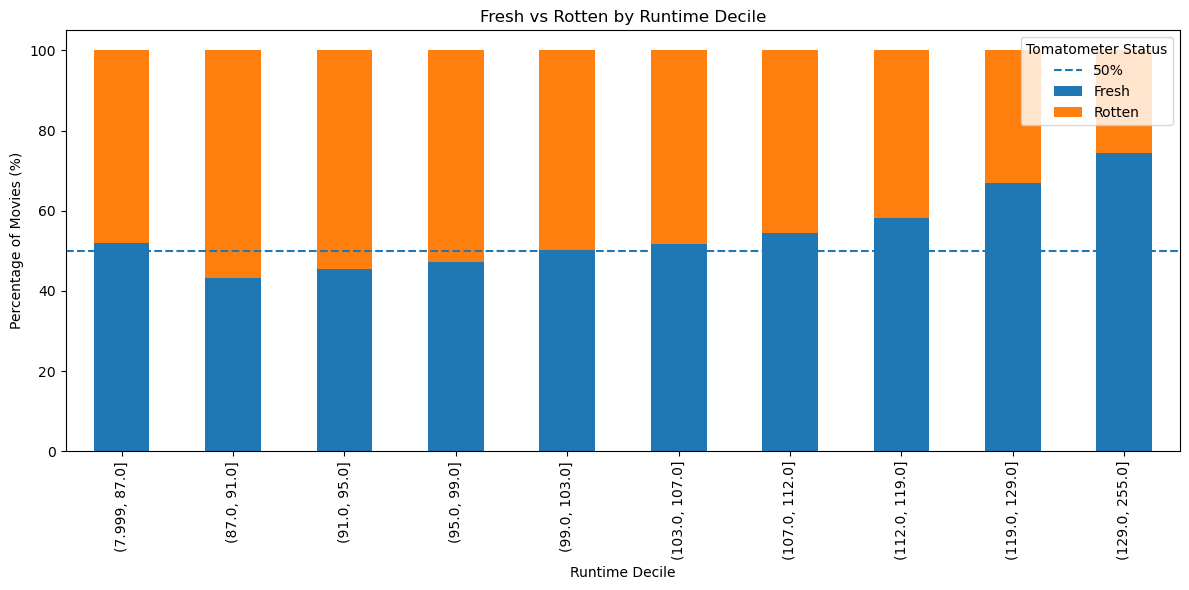

In [122]:
runtime_status.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)
plt.axhline(
    50,
    linestyle='--',
    linewidth=1.5,
    label='50%'
)

plt.title('Fresh vs Rotten by Runtime Decile')
plt.xlabel('Runtime Decile')
plt.ylabel('Percentage of Movies (%)')
plt.legend(title='Tomatometer Status')

plt.tight_layout()
plt.show()

En general a mayor tiempo mejor calificación de la película.

In [123]:
cluster_maps = {
    'directors_cluster': cluster_labels,
    'authors_cluster': cluster_labels_authors,
    'actors_cluster': cluster_labels_actors,
    'production_company_cluster': cluster_labels_production
}

cluster_data = []

for column, mapping in cluster_maps.items():
    temp = filtered_rt_df[
        [column, 'tomatometer_status']
    ].copy()

    temp['cluster_type'] = column.replace('_cluster', '')
    temp['cluster_name'] = temp[column].map(mapping)

    cluster_data.append(
        temp[
            ['cluster_type', 'cluster_name', 'tomatometer_status']
        ]
    )

cluster_data = pd.concat(
    cluster_data,
    ignore_index=True
)

In [124]:
cluster_status = pd.crosstab(
    [cluster_data['cluster_type'], cluster_data['cluster_name']],
    cluster_data['tomatometer_status'],
    normalize='index'
) * 100

cluster_status.round(2)

tomatometer_status                    Fresh  Rotten
cluster_type       cluster_name                    
actors             Established        26.02   73.98
                   Extremely Popular  28.11   71.89
                   Highly Rated       63.24   36.76
                   Low Rated          26.43   73.57
authors            Established        51.19   48.81
                   Extremely Popular  50.54   49.46
                   Highly Rated       72.17   27.83
                   Low Rated          24.63   75.37
directors          Established        23.95   76.05
                   Extremely Popular  56.36   43.64
                   Highly Rated       58.94   41.06
                   Low Rated          71.47   28.53
production_company Established        53.33   46.67
                   Extremely Popular  34.36   65.64
                   Highly Rated       76.96   23.04
                   Low Rated          49.04   50.96

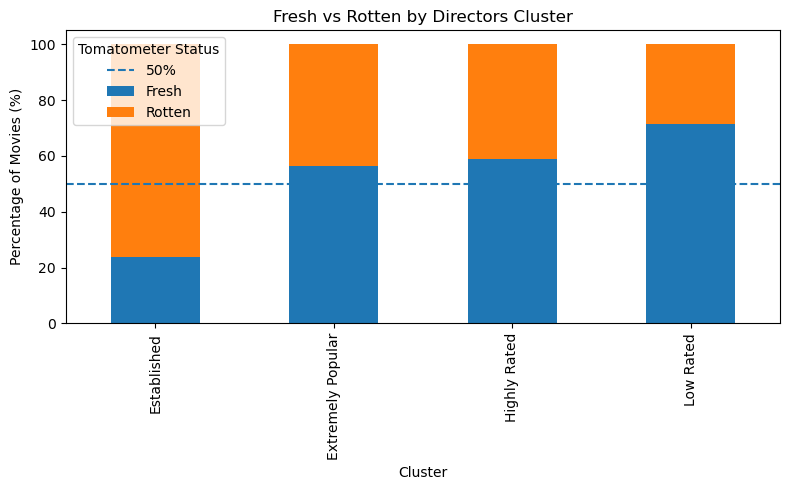

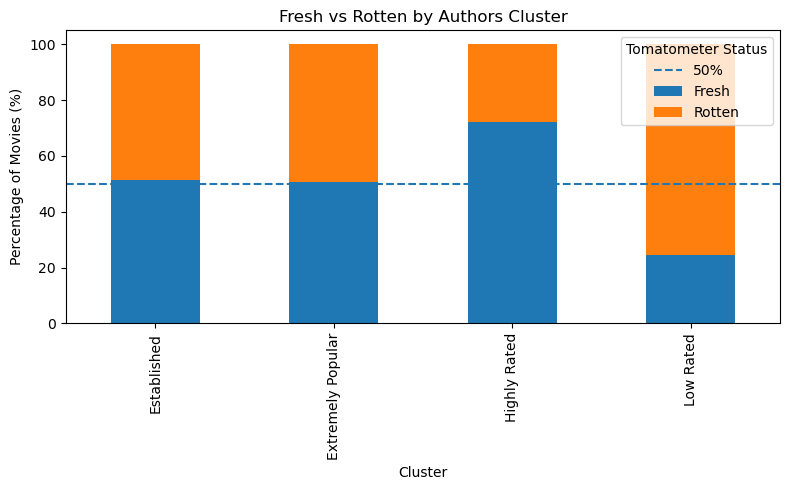

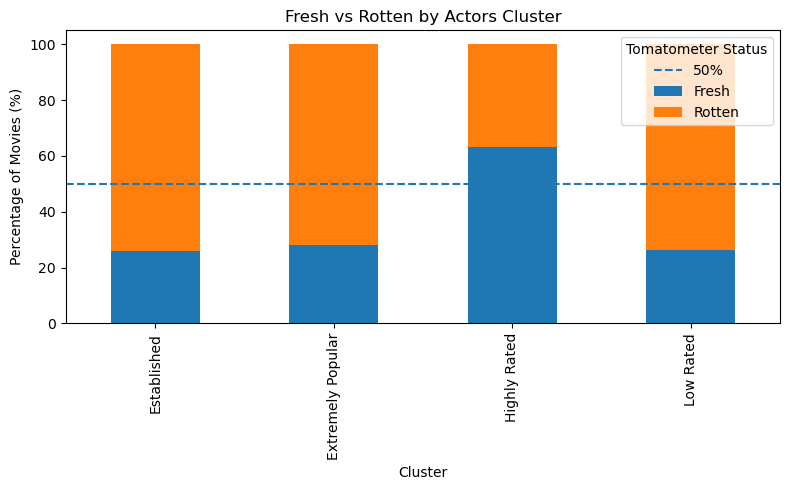

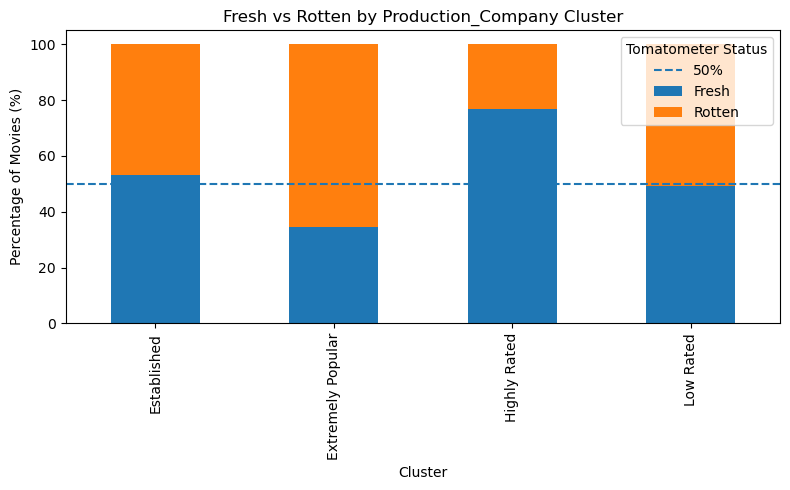

In [125]:
for cluster_type in cluster_data['cluster_type'].unique():

    data = cluster_status.loc[cluster_type]

    data.plot(
        kind='bar',
        stacked=True,
        figsize=(8,5)
    )
    plt.axhline(
    50,
    linestyle='--',
    linewidth=1.5,
    label='50%'
)

    plt.title(f'Fresh vs Rotten by {cluster_type.title()} Cluster')
    plt.xlabel('Cluster')
    plt.ylabel('Percentage of Movies (%)')
    plt.legend(title='Tomatometer Status')

    plt.tight_layout()
    plt.show()

En cuanto a los clusters high y lo pueden definir bastante si va a ser fresh o rotten mientras que para lo que es popular y established puede depender de más variables. 

Podmos definifr que muchas de las peliculas fresh se encontraran en cuando los cluster sean mayoritariamente higly rated, a su vez salvo por los generos mencionados antes puede depender de otras variables y el tiempo tambien tiene algo de peso en la calificación. En cuanto a lo extremadamente popular puede suceder que tengan una película que lanza a la fama el actor y luego el público espera más de lo que el actor puede brindar. 

In [288]:
rt_df = filtered_rt_df.copy()

In [289]:
rt_df_2 = rt_df.copy()

In [290]:
rt_df.columns

Index(['movie_title', 'directors', 'authors', 'actors',
       'original_release_date', 'streaming_release_date', 'runtime',
       'production_company', 'tomatometer_status', 'tomatometer_rating',
       'audience_rating', 'audience_count', 'content_group', 'main_genre',
       'directors_cluster', 'authors_cluster', 'actors_cluster',
       'production_company_cluster', 'target', 'runtime_decile'],
      dtype='object')

In [291]:
# Drop off clusters' original columns
rt_df = rt_df.drop(
    ['directors','authors','actors','production_company', 'tomatometer_rating','audience_rating','audience_count'],
    axis=1
)

In [292]:
rt_df.shape

(8935, 13)

In [293]:
rt_df['streaming_release_date'] = pd.to_datetime(
    rt_df['streaming_release_date']
).dt.year

In [345]:
rt_df.isna().sum()

movie_title                   0
streaming_release_date        0
runtime                       0
content_group                 0
main_genre                    0
directors_cluster             0
authors_cluster               0
actors_cluster                0
production_company_cluster    0
target                        0
dtype: int64

In [295]:
rt_df = rt_df.dropna().copy()

In [296]:
rt_df.shape

(8309, 13)

In [297]:
rt_df.sample(5)

,movie_title,original_release_date,streaming_release_date,runtime,tomatometer_status,content_group,main_genre,directors_cluster,authors_cluster,actors_cluster,production_company_cluster,target,runtime_decile
593,Transporter 2,2005-09-02,2015.0,88.0,Rotten,Teen,Action,2.0,1.0,0.0,1.0,0,"(87.0, 91.0]"
2683,The Astronaut's Wife,1999-08-27,2011.0,109.0,Rotten,Adult,Sci-Fi,1.0,0.0,2.0,2.0,0,"(107.0, 112.0]"
3018,Wall Street,1987-12-11,2015.0,125.0,Fresh,Adult,Drama,2.0,1.0,0.0,1.0,1,"(119.0, 129.0]"
3876,The Founder,2017-01-20,2017.0,115.0,Fresh,Teen,Drama,0.0,3.0,0.0,3.0,1,"(112.0, 119.0]"
555,Lara Croft Tomb Raider - The Cradle of Life,2003-07-21,2013.0,118.0,Rotten,Teen,Action,1.0,1.0,2.0,1.0,0,"(112.0, 119.0]"


In [298]:
rt_df = rt_df.drop(
    ["original_release_date", "runtime_decile", "tomatometer_status"],
    axis=1
)

In [299]:
# Now, let´s define x (features) and y (target)
X = rt_df.drop(columns = ['target','movie_title'])
y = rt_df['target']

In [300]:
rt_df.head()

,movie_title,streaming_release_date,runtime,content_group,main_genre,directors_cluster,authors_cluster,actors_cluster,production_company_cluster,target
0,Titanic,2014.0,195.0,Teen,Drama,3.0,2.0,2.0,1.0,1
1,The Lord of the Rings: The Return of the King,2010.0,200.0,Teen,Action,3.0,2.0,2.0,3.0,1
2,Spider-Man,2013.0,116.0,Teen,Action,3.0,2.0,2.0,3.0,1
3,Shrek 2,2015.0,92.0,Family,Comedy,3.0,2.0,2.0,0.0,1
4,Harry Potter and the Goblet of Fire,2008.0,157.0,Teen,Action,3.0,2.0,2.0,1.0,1


### Perform Train, Test, Split

In [301]:
# Use stratify, beacuse the y is a categorical target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y)

print(X_train.shape)
print(X_test.shape)

(6647, 8)
(1662, 8)


In [302]:
categorical_cols = [
    'content_group',
    'main_genre',
    'directors_cluster',
    'authors_cluster',
    'actors_cluster',
    'production_company_cluster'
]
categorical_cols = [
    'content_group',
    'main_genre',
    'directors_cluster',
    'authors_cluster',
    'actors_cluster',
    'production_company_cluster'
]

X_train = pd.get_dummies(
    X_train,
    columns=categorical_cols,
    drop_first=True
).astype(int)

X_test = pd.get_dummies(
    X_test,
    columns=categorical_cols,
    drop_first=True
).astype(int)

X_test = X_test.reindex(
    columns=X_train.columns,
    fill_value=0
)

In [303]:
X_train.head()

,streaming_release_date,runtime,content_group_Family,content_group_Teen,content_group_Unknown,main_genre_Comedy,main_genre_Documentary,main_genre_Drama,main_genre_Family,main_genre_Horror,...,directors_cluster_3.0,authors_cluster_1.0,authors_cluster_2.0,authors_cluster_3.0,actors_cluster_1.0,actors_cluster_2.0,actors_cluster_3.0,production_company_cluster_1.0,production_company_cluster_2.0,production_company_cluster_3.0
3326,2016,96,0,1,0,1,0,0,0,0,...,0,1,0,0,0,0,0,1,0,0
7686,2016,104,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,1,0
7680,2017,95,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,1,0
2055,2015,118,0,1,0,1,0,0,0,0,...,1,0,0,0,0,0,0,1,0,0
8506,2016,107,0,0,1,1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0


In [304]:
# For numerical columns, normalize with MinMax Scaler
num_cols = ['runtime']

scaler = MinMaxScaler()
scaler.set_output(transform="pandas")  # mantém nomes das colunas
# set_output(transform="pandas") makes the scaler return a DataFrame (keeps the real column names and index)

# Fit ONLY on X_train --> avoids leaking any information from the test set into the scaling parameters
X_train_scaled_df = scaler.fit_transform(X_train)

# Then apply that same transformation to X_test
X_test_scaled_df = scaler.transform(X_test)

In [305]:
#Let´s check the results before and after MinMax Scaler

# BEFORE: original scale
print('BEFORE scaling (X_train):')
print(X_train.describe().loc[['mean', 'std']].round(4))
print()

# AFTER: standardized scale
print('AFTER scaling (X_train):')
print(X_train_scaled_df.describe().loc[['mean', 'std']].round(4))

BEFORE scaling (X_train):
      streaming_release_date   runtime  content_group_Family  \
mean               2014.8652  106.1216                0.2076   
std                   2.4730   18.8586                0.4056   

      content_group_Teen  content_group_Unknown  main_genre_Comedy  \
mean              0.2574                 0.0901             0.3219   
std               0.4372                 0.2864             0.4673   

      main_genre_Documentary  main_genre_Drama  main_genre_Family  \
mean                  0.0159            0.3034             0.0074   
std                   0.1253            0.4598             0.0855   

      main_genre_Horror  ...  directors_cluster_3.0  authors_cluster_1.0  \
mean             0.0450  ...                 0.0462               0.3090   
std              0.2073  ...                 0.2099               0.4621   

      authors_cluster_2.0  authors_cluster_3.0  actors_cluster_1.0  \
mean               0.0394               0.4116              0.0

In [306]:
# Step 4 - Model Training: SGDClassifier
# --------------------------------------

# loss='log_loss' --> same Sigmoid + Cost Function from the theory!
sgd_model = SGDClassifier(loss='log_loss', random_state=SEED)
sgd_model.fit(X_train_scaled_df, y_train)  # Fit on train

# The learned weights (w) = one per feature
weights = pd.Series(sgd_model.coef_[0], index=X_train_scaled_df.columns)
# In Regression the answer is a single continuous value --> one coefficient vector --> coef_
# In binary Classification the answer is also a single outcome --> one coefficient vector --> coef_[0]
# (already distinguishes between the two classes) 
# In multiclass Classification, each class needs its own weight vectors --> coef_[0], coef_[1], coef_[2]...

# Sorted by |w| so it is easy to read, but keeping the sign to show the direction of the effect
print('Learned weights (Wi):')
print(weights.round(4).reindex(abs(weights).sort_values(ascending=False).index))

# worst texture, radius error AND worst concavity/symmetry have high W ---> these matter the most! Why?

Learned weights (Wi):
runtime                           2.1191
main_genre_Documentary            1.8161
content_group_Unknown             1.4936
actors_cluster_3.0               -1.3198
authors_cluster_3.0               1.0504
production_company_cluster_2.0   -1.0295
actors_cluster_2.0               -0.9218
directors_cluster_1.0            -0.9002
authors_cluster_2.0               0.8771
streaming_release_date            0.7847
production_company_cluster_3.0   -0.7410
actors_cluster_1.0               -0.6337
content_group_Teen               -0.5747
production_company_cluster_1.0   -0.5350
authors_cluster_1.0               0.4004
main_genre_Sci-Fi                 0.3563
main_genre_Other                 -0.2693
directors_cluster_3.0             0.2436
main_genre_Drama                  0.2151
main_genre_Comedy                 0.1826
main_genre_Romance                0.1760
directors_cluster_2.0            -0.1639
main_genre_Family                 0.1374
content_group_Family             -0

In [307]:
# Step 5 - Results
# ----------------

# Evaluate the model on both Train and Test, to check for overfitting
y_pred_train = sgd_model.predict(X_train_scaled_df)     # train
y_pred_test = sgd_model.predict(X_test_scaled_df)       # test

accuracy_train = accuracy_score(y_train, y_pred_train)  # train, just to compare with the report below
print(f'Accuracy (Train): {accuracy_train * 100:.2f}%')
print()

# Classification Report (Test)
# ----------------------------
print(classification_report(y_test, y_pred_test, target_names=['Fresh', 'Rotten']))

Accuracy (Train): 74.12%

              precision    recall  f1-score   support

       Fresh       0.74      0.67      0.70       775
      Rotten       0.73      0.80      0.76       887

    accuracy                           0.74      1662
   macro avg       0.74      0.73      0.73      1662
weighted avg       0.74      0.74      0.74      1662



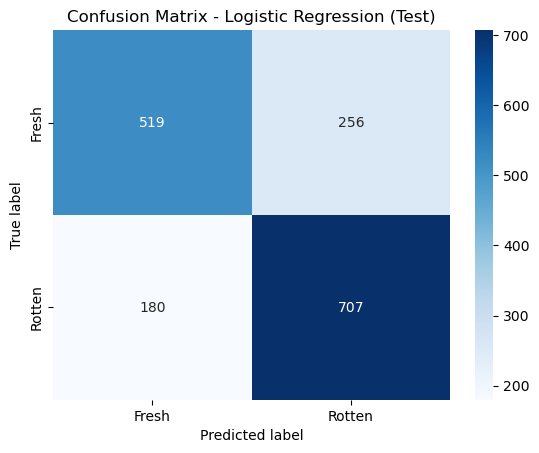

In [308]:
# Confusion Matrix (Test)
# -----------------------

cm = confusion_matrix(y_test, y_pred_test)

# After remapping, 0 = benign, 1 = malignant --> use this order, NOT
# cancer_data.target_names (that one still reflects sklearn's ORIGINAL order)
class_labels = ['Fresh', 'Rotten']

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.title('Confusion Matrix - Logistic Regression (Test)')
plt.show()

In [309]:
#THE MODEL IS UNDERFITTING WITH A PRESICION OF 74%

## Decision tree

In [310]:
# Step 4 - Model Training: Decision Tree Classifier
# -------------------------------------------------

# Let's see if a single tree overfits here too:
tree_clf = DecisionTreeClassifier(random_state=SEED)
tree_clf.fit(X_train, y_train)

print("Model Trained!")

Model Trained!


In [311]:
# Step 5 - Results
# ----------------

y_pred_train = tree_clf.predict(X_train)
y_pred_test = tree_clf.predict(X_test)

acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)

print(f'Accuracy (Train): {acc_train * 100:.2f}%')
print(f'Accuracy (Test): {acc_test * 100:.2f}%')
print()
print('Classification Report (Test):')
print(classification_report(y_test, y_pred_test))

Accuracy (Train): 98.60%
Accuracy (Test): 63.36%

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.61      0.60      0.60       775
           1       0.65      0.66      0.66       887

    accuracy                           0.63      1662
   macro avg       0.63      0.63      0.63      1662
weighted avg       0.63      0.63      0.63      1662



In [312]:
#USLESS DESITION TREE

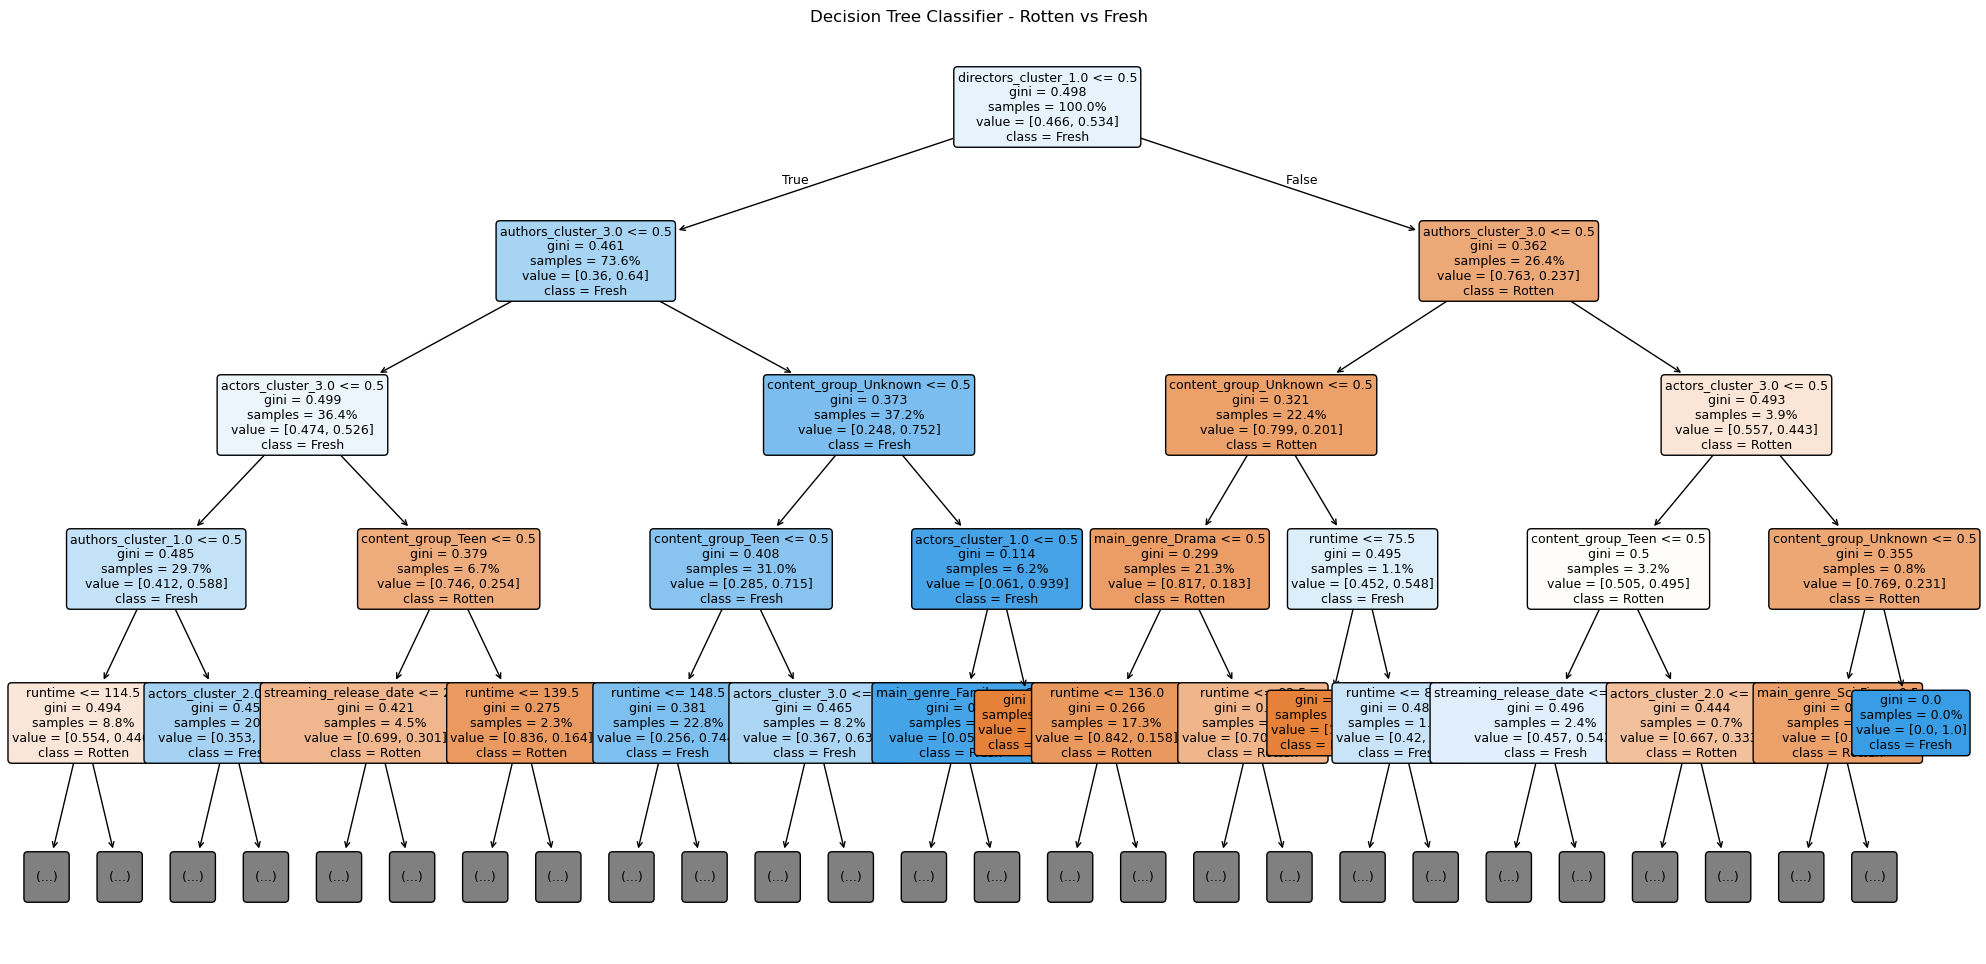

In [313]:
# Step 6 - Model Analysis: visualize the tree
# -------------------------------------------
plt.figure(figsize=(25, 12))

plot_tree(
    tree_clf,
    feature_names=X_train.columns,
    class_names=['Rotten', 'Fresh'],
    filled=True,
    fontsize=9,
    rounded=True,
    proportion=True,
    max_depth=4
)

plt.title(
    'Decision Tree Classifier - Rotten vs Fresh'
)

plt.show()

## Random Forest

In [314]:
# Step 4 - Model Training: Random Forest Classifier
# -------------------------------------------------

# No max_depth cap, same approach as the Regressor
rf_clf = RandomForestClassifier(
    n_estimators=150,
    min_samples_split=3,
    min_samples_leaf=2,
    max_features=3,      # sqrt rule for Classification: sqrt(6) = 2.45 --> rounded to 2
    random_state=SEED)

rf_clf.fit(X_train, y_train)
print("Model Trained!")

Model Trained!


In [315]:
# Step 5 - Results
# ----------------

y_pred_train = rf_clf.predict(X_train)
y_pred_test = rf_clf.predict(X_test)

acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)

print(f'Accuracy (Train): {acc_train * 100:.2f}%')
print(f'Accuracy (Test): {acc_test * 100:.2f}%')
print()
print('Classification Report (Test):')
print(classification_report(y_test, y_pred_test))

Accuracy (Train): 83.75%
Accuracy (Test): 73.65%

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.74      0.67      0.70       775
           1       0.73      0.80      0.76       887

    accuracy                           0.74      1662
   macro avg       0.74      0.73      0.73      1662
weighted avg       0.74      0.74      0.74      1662



In [316]:
#This one have a bigger overfittig but a better accuracy. 

In [317]:
## XGBOOST and Random search

In [318]:
# Step 4 - Model Training: Random Search over XGBoost Regressor
# -------------------------------------------------------------

# The grid: the same 5 hyperparameters we actually tuned by hand in Section 4
grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]}
xgb_class = XGBClassifier(random_state=SEED)

# cv=4 --> same Cross Validation with K=4
# n_iter=10 --> instead of trying all combinations, only 10 random ones are sampled
model = RandomizedSearchCV(estimator=xgb_class,
                           param_distributions=grid,
                           n_iter=20,
                           cv=5,
                           scoring='accuracy',
                           random_state=SEED,      # So all the random iterations are the same
                           n_jobs=-1)              # n_jobs=-1 --> allows multicore CPU processing
model.fit(X_train, y_train)

print("Model Trained!")

Model Trained!


In [319]:
# Step 5 - Results
# ----------------

# Best combination found by Random Search
print('Best hyperparameters found:')
print(model.best_params_)
print()

Best hyperparameters found:
{'subsample': 1.0, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.6}



## XG Boost - Original

In [320]:
# First, let´s create an XGBoost classifier configured for binary classification
# Once we have a very large df, we are gonna to consider tree_method="hist" to help with XG Boost performance

xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",   
    random_state=SEED
)

In [321]:
# Now, let´s define probability distributions for each hyperparameter, from which random values are sampled (Random Search) 

param_dist = {
    "n_estimators": np.arange(100, 1500, 100),
    "learning_rate": np.linspace(0.01, 0.3, 30),
    "max_depth": np.arange(3, 15),
    "min_child_weight": np.arange(1, 10),
    "gamma": np.linspace(0, 0.5, 20),
    "subsample": np.linspace(0.5, 1.0, 20),
    "colsample_bytree": np.linspace(0.5, 1.0, 20)
}

In [322]:
# Perform Random Search to explore a wide range of hyperparameter combinations:
# n_iter=50 means the search will test 50 random combinations from param_dist.
# cv=3 applies 3-fold cross-validation for each combination --- before we tried with cv=5, but it was too heavy run 250 fits
# n_jobs=-1 uses all available CPU cores to speed up the search.

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=50,        
    scoring="accuracy",
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=SEED
)

random_search.fit(X_train, y_train)

Fitting 3 folds for each of 50 candidates, totalling 150 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': array([0.5 ..., 1. ]), 'gamma': array([0. ..., 0.5 ]), 'learning_rate': array([0.01, ..., 0.29, 0.3 ]), 'max_depth': array([ 3, 4..., 12, 13, 14]), ...}"
,n_iter,50
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,1
,error_score,nan


In [323]:
# Extract the best model found during Random Search

best_random_model = random_search.best_estimator_
best_random_params = random_search.best_params_

In [324]:
# Create a refined hyperparameter grid for Grid Search.
# Grid Search tests all combinations in this smaller, focused grid.
# The grid is centered around the best parameters found by Random Search.

param_grid = {
    "n_estimators": [best_random_params["n_estimators"] - 100,
                     best_random_params["n_estimators"],
                     best_random_params["n_estimators"] + 100],

    "learning_rate": [best_random_params["learning_rate"] * 0.5,
                      best_random_params["learning_rate"],
                      best_random_params["learning_rate"] * 1.5],

    "max_depth": [best_random_params["max_depth"] - 1,
                  best_random_params["max_depth"],
                  best_random_params["max_depth"] + 1]
}

In [325]:
# Create the GridSearchCV object using the refined hyperparameter grid.
# Grid Search will test all combinations inside param_grid using cross-validation.

from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    estimator=xgb,          # the XGBoost model
    param_grid=param_grid,  # refined hyperparameter grid
    scoring="accuracy",     # evaluation metric
    cv=3,                   # number of folds (lighter than cv=5)
    verbose=1,              # show progress during fitting
    n_jobs=-1               # use all CPU cores
)

# Fit the Grid Search on the training data.
# This step performs an exhaustive search over all hyperparameter combinations.

grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 27 candidates, totalling 81 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'learning_rate': [np.float64(0.015), np.float64(0.03), ...], 'max_depth': [np.int64(8), np.int64(9), ...], 'n_estimators': [np.int64(0), np.int64(100), ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


In [326]:
# Extract the final best model found by Grid Search.
# This model contains the optimal hyperparameters after exhaustive tuning.

best_model = grid_search.best_estimator_

In [327]:
# Display the optimal hyperparameters selected by Grid Search.
# Useful for documentation and understanding how the model was tuned.

grid_search.best_params_

{'learning_rate': np.float64(0.045),
 'max_depth': np.int64(8),
 'n_estimators': np.int64(100)}

In [328]:
# Use the final tuned XGBoost model to make predictions on the test set.
# The output is a binary classification: 1 (Fresh) or 0 (Rotten).
pred = best_model.predict(X_test)

In [329]:
# Evaluate the model using standard classification metrics.
# Accuracy: overall correctness.
# classification_report: precision, recall, and F1-score.
# confusion_matrix: distribution of correct and incorrect predictions.
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))
print(confusion_matrix(y_test, pred))

Accuracy: 0.7268351383874849
              precision    recall  f1-score   support

           0       0.73      0.65      0.69       775
           1       0.72      0.79      0.76       887

    accuracy                           0.73      1662
   macro avg       0.73      0.72      0.72      1662
weighted avg       0.73      0.73      0.73      1662

[[506 269]
 [185 702]]


In [330]:
# Check the train accuracy to see if there is overfitting

train_pred = best_model.predict(X_train)
print("Train Accuracy:", accuracy_score(y_train, train_pred))

Train Accuracy: 0.8003610651421694


## XG Boost - Manually Tuned

In [331]:
# This model uses controlled hyperparameters to reduce overfitting
# and improve generalization compared to the initial version.

xgb_tuned = XGBClassifier(
    objective="binary:logistic",  # binary classification (Fresh vs Rotten)
    eval_metric="logloss",        # evaluation metric used during training
    max_depth=3,                  # we´ve tried max_depth with 4 and 5, but 3 had the best accuracy rate result
    learning_rate=0.1,            # moderate learning rate for stable boosting
    n_estimators=300,             # more boosting rounds for better learning
    subsample=0.8,                # use 80% of rows per tree to improve generalization
    colsample_bytree=0.8,         # use 80% of features per tree to reduce variance
    reg_alpha=0.5,                # L1 regularization to reduce model complexity
    reg_lambda=1.0,               # L2 regularization for stability
    tree_method="hist",           # fast histogram-based algorithm
    random_state=SEED             # reproducibility
)

In [332]:
# Fit the manually tuned XGBoost model.

xgb_tuned.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [333]:
# Make predictions on the test set using the tuned XGBoost model.
# The model outputs binary predictions: 1 (Fresh) or 0 (Rotten).

pred_tuned = xgb_tuned.predict(X_test)

In [334]:
# Evaluate the tuned model using standard classification metrics.
# Accuracy: overall correctness.
# classification_report: precision, recall, and F1-score for each class.
# confusion_matrix: distribution of correct and incorrect predictions.

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Tuned Model - Test Accuracy:", accuracy_score(y_test, pred_tuned))
print(classification_report(y_test, pred_tuned))
print(confusion_matrix(y_test, pred_tuned))

Tuned Model - Test Accuracy: 0.7436823104693141
              precision    recall  f1-score   support

           0       0.75      0.67      0.71       775
           1       0.74      0.81      0.77       887

    accuracy                           0.74      1662
   macro avg       0.75      0.74      0.74      1662
weighted avg       0.74      0.74      0.74      1662

[[518 257]
 [169 718]]


In [335]:
# Check the train accuracy to see if there is overfitting

train_pred_tuned = xgb_tuned.predict(X_train)
print("Tuned Model - Train Accuracy:", accuracy_score(y_train, train_pred_tuned))

Tuned Model - Train Accuracy: 0.7738829547164134


## Model Comparison — Original vs Tuned XGBoost

- The original XGBoost model worked as a baseline and delivered reasonable performance, but showed signs of overfitting.
- After manual tuning, the tuned model achieved better generalization.
- Test accuracy improved from 0.7268 → 0.7437, and both classes showed higher F1-scores.
- The tuned model also reduced the gap between training and test performance.
- These improvements show that the tuned model learns more stable patterns and is the best choice as the final model for this project.

## Model Test

In [336]:
# Select 10 movies that are actually Rotten from the Test set
rotten_test = filtered_rt_df.loc[X_test.index]

rotten_sample = rotten_test[
    rotten_test['target'] == 0
].sample(
    n=10,
    random_state=SEED
)

rotten_sample[['movie_title', 'tomatometer_status', 'target']]

,movie_title,tomatometer_status,target
6492,Fulltime Killer,Rotten,0
1937,Ride Along,Rotten,0
7001,Stroker Ace,Rotten,0
8251,Dead Man's Curve,Rotten,0
5280,The Gunman,Rotten,0
312,The Twilight Saga: New Moon,Rotten,0
6498,Ma,Rotten,0
7624,Intruders,Rotten,0
155,Men in Black II,Rotten,0
1265,National Lampoon's Van Wilder,Rotten,0


In [337]:
X_rotten_sample = X_test.loc[rotten_sample.index]

y_pred_rotten = xgb_tuned.predict(X_rotten_sample)
y_prob_rotten = xgb_tuned.predict_proba(X_rotten_sample)[:, 1]

In [338]:
rotten_results = pd.DataFrame({
    'Movie': rotten_sample['movie_title'],
    'Actual': rotten_sample['target'],
    'Predicted': y_pred_rotten,
    'Fresh Probability': y_prob_rotten
})

rotten_results['Actual'] = rotten_results['Actual'].map({
    0: 'Rotten',
    1: 'Fresh'
})

rotten_results['Predicted'] = rotten_results['Predicted'].map({
    0: 'Rotten',
    1: 'Fresh'
})

rotten_results

,Movie,Actual,Predicted,Fresh Probability
6492,Fulltime Killer,Rotten,Fresh,0.818890
1937,Ride Along,Rotten,Rotten,0.276210
7001,Stroker Ace,Rotten,Fresh,0.778411
8251,Dead Man's Curve,Rotten,Fresh,0.513185
5280,The Gunman,Rotten,Rotten,0.190329
312,The Twilight Saga: New Moon,Rotten,Rotten,0.203864
6498,Ma,Rotten,Fresh,0.754955
7624,Intruders,Rotten,Rotten,0.211361
155,Men in Black II,Rotten,Rotten,0.346955
1265,National Lampoon's Van Wilder,Rotten,Rotten,0.215484


In [339]:
correct_rotten = (y_pred_rotten == 0).sum()

print(f'Correctly identified Rotten: {correct_rotten}/10')
print(f'Accuracy on Rotten sample: {correct_rotten / 10 * 100:.2f}%')

Correctly identified Rotten: 6/10
Accuracy on Rotten sample: 60.00%


In [340]:
# -----------------------------
# Test XGBoost with a The amazing spiderman
# -----------------------------

new_movie = pd.DataFrame({
    'streaming_release_date': [2013],
    'runtime': [116],
    'content_group': ['Teen'],
    'main_genre': ['Action'],
    'directors_cluster': [3],
    'authors_cluster': [2],
    'actors_cluster': [2],
    'production_company_cluster': [3]
})

# Clusters must have the same dtype used during training
cluster_cols = [
    'directors_cluster',
    'authors_cluster',
    'actors_cluster',
    'production_company_cluster'
]

new_movie[cluster_cols] = new_movie[cluster_cols].astype(float)

# One-hot encoding
# IMPORTANT: do NOT use drop_first=True here
new_movie_encoded = pd.get_dummies(
    new_movie,
    columns=[
        'content_group',
        'main_genre',
        'directors_cluster',
        'authors_cluster',
        'actors_cluster',
        'production_company_cluster'
    ],
    drop_first=False
)

# Make sure the columns are exactly the same as the training data
new_movie_encoded = new_movie_encoded.reindex(
    columns=X_train.columns,
    fill_value=0
)

# IMPORTANT:
# XGBoost was trained with X_train, NOT X_train_scaled_df
prediction = xgb_tuned.predict(new_movie_encoded)
probability = xgb_tuned.predict_proba(new_movie_encoded)

print("Prediction:", "Fresh" if prediction[0] == 1 else "Rotten")
print(f"Rotten probability: {probability[0][0]:.2%}")
print(f"Fresh probability: {probability[0][1]:.2%}")

Prediction: Rotten
Rotten probability: 51.49%
Fresh probability: 48.51%


In [341]:
# -----------------------------
# Test XGBoost with Spiderman 2014
# -----------------------------

new_movie = pd.DataFrame({
    'streaming_release_date': [2014],
    'runtime': [145],
    'content_group': ['Teen'],
    'main_genre': ['Action'],
    'directors_cluster': [0],
    'authors_cluster': [2],
    'actors_cluster': [0],
    'production_company_cluster': [3]
})

# Clusters must have the same dtype used during training
cluster_cols = [
    'directors_cluster',
    'authors_cluster',
    'actors_cluster',
    'production_company_cluster'
]

new_movie[cluster_cols] = new_movie[cluster_cols].astype(float)

# One-hot encoding
# IMPORTANT: do NOT use drop_first=True here
new_movie_encoded = pd.get_dummies(
    new_movie,
    columns=[
        'content_group',
        'main_genre',
        'directors_cluster',
        'authors_cluster',
        'actors_cluster',
        'production_company_cluster'
    ],
    drop_first=False
)

# Make sure the columns are exactly the same as the training data
new_movie_encoded = new_movie_encoded.reindex(
    columns=X_train.columns,
    fill_value=0
)

# IMPORTANT:
# XGBoost was trained with X_train, NOT X_train_scaled_df
prediction = xgb_tuned.predict(new_movie_encoded)
probability = xgb_tuned.predict_proba(new_movie_encoded)

print("Prediction:", "Fresh" if prediction[0] == 1 else "Rotten")
print(f"Rotten probability: {probability[0][0]:.2%}")
print(f"Fresh probability: {probability[0][1]:.2%}")

Prediction: Fresh
Rotten probability: 43.38%
Fresh probability: 56.62%


In [342]:
# -----------------------------
# Test XGBoost with Spiderman 2026
# -----------------------------

new_movie = pd.DataFrame({
    'streaming_release_date': [2026],
    'runtime': [145],
    'content_group': ['Teen'],
    'main_genre': ['Action'],
    'directors_cluster': [0],
    'authors_cluster': [0],
    'actors_cluster': [0],
    'production_company_cluster': [3]
})

# Clusters must have the same dtype used during training
cluster_cols = [
    'directors_cluster',
    'authors_cluster',
    'actors_cluster',
    'production_company_cluster'
]

new_movie[cluster_cols] = new_movie[cluster_cols].astype(float)

# One-hot encoding
# IMPORTANT: do NOT use drop_first=True here
new_movie_encoded = pd.get_dummies(
    new_movie,
    columns=[
        'content_group',
        'main_genre',
        'directors_cluster',
        'authors_cluster',
        'actors_cluster',
        'production_company_cluster'
    ],
    drop_first=False
)

# Make sure the columns are exactly the same as the training data
new_movie_encoded = new_movie_encoded.reindex(
    columns=X_train.columns,
    fill_value=0
)

# IMPORTANT:
# XGBoost was trained with X_train, NOT X_train_scaled_df
prediction = xgb_tuned.predict(new_movie_encoded)
probability = xgb_tuned.predict_proba(new_movie_encoded)

print("Prediction:", "Fresh" if prediction[0] == 1 else "Rotten")
print(f"Rotten probability: {probability[0][0]:.2%}")
print(f"Fresh probability: {probability[0][1]:.2%}")

Prediction: Fresh
Rotten probability: 43.76%
Fresh probability: 56.24%


In [343]:
spiderman_movies = rt_movies_df[
    rt_movies_df["movie_title"].str.contains("spider-man", case=False, na=False)
]

spiderman_movies[["movie_title", "original_release_date"]]

,movie_title,original_release_date
2,Spider-Man,2002-05-03
55,Spider-Man 3,2007-05-04
94,Spider-Man 2,2004-06-30
197,The Amazing Spider-Man,2012-07-03
1167,The Amazing Spider-Man 2,2014-05-02
1846,Spider-Man: Homecoming,2017-07-07
2372,Spider-Man: Far From Home,2019-07-02
4687,Spider-Man: Into the Spider-Verse,2018-12-14


In [346]:
# Buscar todas las películas de Spider-Man
spiderman = rt_df_2 [
    rt_df_2 ["movie_title"].str.contains("spider", case=False, na=False)
].copy()

spiderman[["movie_title", "original_release_date", "target"]]

,movie_title,original_release_date,target
2,Spider-Man,2002-05-03,1
55,Spider-Man 3,2007-05-04,1
94,Spider-Man 2,2004-06-30,1
197,The Amazing Spider-Man,2012-07-03,1
748,The Spiderwick Chronicles,2008-01-31,1
1167,The Amazing Spider-Man 2,2014-05-02,0
1451,Along Came a Spider,2001-04-06,0
1846,Spider-Man: Homecoming,2017-07-07,1
2372,Spider-Man: Far From Home,2019-07-02,1
4687,Spider-Man: Into the Spider-Verse,2018-12-14,1


In [350]:
# Select Spider-Man movies
spiderman = rt_df[
    rt_df["movie_title"].str.contains("spider-man", case=False, na=False)
].copy()

# Use EXACTLY the same original features used to train the model
X_spiderman = spiderman[X.columns].copy()

# One-hot encoding: same process as training
X_spiderman = pd.get_dummies(
    X_spiderman,
    columns=categorical_cols,
    drop_first=True
)

# Make columns identical to X_train
X_spiderman = X_spiderman.reindex(
    columns=X_train.columns,
    fill_value=0
)

# Check
print(X_spiderman.shape)
print(X_spiderman.dtypes.value_counts())

(8, 26)
int64      19
bool        5
float64     2
Name: count, dtype: int64


In [351]:
y_pred_spiderman = xgb_tuned.predict(X_spiderman)

y_prob_spiderman = (
    xgb_tuned.predict_proba(X_spiderman)[:, 1]
)

In [352]:
spiderman_results = pd.DataFrame({
    'Movie': spiderman['movie_title'].values,
    'Actual': spiderman['target'].values,
    'Predicted': y_pred_spiderman,
    'Fresh Probability': y_prob_spiderman
})

spiderman_results['Actual'] = spiderman_results['Actual'].map({
    0: 'Rotten',
    1: 'Fresh'
})

spiderman_results['Predicted'] = spiderman_results['Predicted'].map({
    0: 'Rotten',
    1: 'Fresh'
})

spiderman_results

,Movie,Actual,Predicted,Fresh Probability
0,Spider-Man,Fresh,Fresh,0.642430
1,Spider-Man 3,Fresh,Rotten,0.247373
2,Spider-Man 2,Fresh,Rotten,0.482511
3,The Amazing Spider-Man,Fresh,Fresh,0.824664
4,The Amazing Spider-Man 2,Rotten,Fresh,0.554786
5,Spider-Man: Homecoming,Fresh,Fresh,0.866814
6,Spider-Man: Far From Home,Fresh,Fresh,0.828477
7,Spider-Man: Into the Spider-Verse,Fresh,Fresh,0.688728
